# Introduction: Home Credit Default Risk Competition

This notebook is intended for those who are new to machine learning competitions or want a gentle introduction to the problem. I purposely avoid jumping into complicated models or joining together lots of data in order to show the basics of how to get started in machine learning! Any comments or suggestions are much appreciated.

In this notebook, we will take an initial look at the Home Credit default risk machine learning competition currently hosted on Kaggle. The objective of this competition is to use historical loan application data to predict whether or not an applicant will be able to repay a loan. This is a standard supervised classification task:

* __Supervised__: The labels are included in the training data and the goal is to train a model to learn to predict the labels from the features
* __Classification__: The label is a binary variable, 0 (will repay loan on time), 1 (will have difficulty repaying loan)


# Data

The data is provided by [Home Credit](http://www.homecredit.net/about-us.aspx), a service dedicated to provided lines of credit (loans) to the unbanked population. Predicting whether or not a client will repay a loan or have difficulty is a critical business need, and Home Credit is hosting this competition on Kaggle to see what sort of models the machine learning community can develop to help them in this task. 

There are 7 different sources of data:

* application_train/application_test: the main training and testing data with information about each loan application at Home Credit. Every loan has its own row and is identified by the feature `SK_ID_CURR`. The training application data comes with the `TARGET` indicating 0: the loan was repaid or 1: the loan was not repaid. 
* bureau: data concerning client's previous credits from other financial institutions. Each previous credit has its own row in bureau, but one loan in the application data can have multiple previous credits.
* bureau_balance: monthly data about the previous credits in bureau. Each row is one month of a previous credit, and a single previous credit can have multiple rows, one for each month of the credit length. 
* previous_application: previous applications for loans at Home Credit of clients who have loans in the application data. Each current loan in the application data can have multiple previous loans. Each previous application has one row and is identified by the feature `SK_ID_PREV`. 
* POS_CASH_BALANCE: monthly data about previous point of sale or cash loans clients have had with Home Credit. Each row is one month of a previous point of sale or cash loan, and a single previous loan can have many rows.
* credit_card_balance: monthly data about previous credit cards clients have had with Home Credit. Each row is one month of a credit card balance, and a single credit card can have many rows.
* installments_payment: payment history for previous loans at Home Credit. There is one row for every made payment and one row for every missed payment. 

This diagram shows how all of the data is related:

![image](https://storage.googleapis.com/kaggle-media/competitions/home-credit/home_credit.png)

Moreover, we are provided with the definitions of all the columns (in `HomeCredit_columns_description.csv`) and an example of the expected submission file. 

In this notebook, we will stick to using only the main application training and testing data. Although if we want to have any hope of seriously competing, we need to use all the data, for now we will stick to one file which should be more manageable. This will let us establish a baseline that we can then improve upon. With these projects, it's best to build up an understanding of the problem a little at a time rather than diving all the way in and getting completely lost! 

## Metric: ROC AUC

Once we have a grasp of the data (reading through the [column descriptions](https://www.kaggle.com/c/home-credit-default-risk/data) helps immensely), we need to understand the metric by which our submission is judged. In this case, it is a common classification metric known as the [Receiver Operating Characteristic Area Under the Curve (ROC AUC, also sometimes called AUROC)](https://stats.stackexchange.com/questions/132777/what-does-auc-stand-for-and-what-is-it).

The ROC AUC may sound intimidating, but it is relatively straightforward once you can get your head around the two individual concepts. The [Reciever Operating Characteristic (ROC) curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) graphs the true positive rate versus the false positive rate:

![image](http://www.statisticshowto.com/wp-content/uploads/2016/08/ROC-curve.png)

A single line on the graph indicates the curve for a single model, and movement along a line indicates changing the threshold used for classifying a positive instance. The threshold starts at 0 in the upper right to and goes to 1 in the lower left. A curve that is to the left and above another curve indicates a better model. For example, the blue model is better than the red model, which is better than the black diagonal line which indicates a naive random guessing model. 

The [Area Under the Curve (AUC)](http://gim.unmc.edu/dxtests/roc3.htm) explains itself by its name! It is simply the area under the ROC curve. (This is the integral of the curve.) This metric is between 0 and 1 with a better model scoring higher. A model that simply guesses at random will have an ROC AUC of 0.5.

When we measure a classifier according to the ROC AUC, we do not generation 0 or 1 predictions, but rather a probability between 0 and 1. This may be confusing because we usually like to think in terms of accuracy, but when we get into problems with inbalanced classes (we will see this is the case), accuracy is not the best metric. For example, if I wanted to build a model that could detect terrorists with 99.9999% accuracy, I would simply make a model that predicted every single person was not a terrorist. Clearly, this would not be effective (the recall would be zero) and we use more advanced metrics such as ROC AUC or the [F1 score](https://en.wikipedia.org/wiki/F1_score) to more accurately reflect the performance of a classifier. A model with a high ROC AUC will also have a high accuracy, but the [ROC AUC is a better representation of model performance.](https://datascience.stackexchange.com/questions/806/advantages-of-auc-vs-standard-accuracy)

Not that we know the background of the data we are using and the metric to maximize, let's get into exploring the data. In this notebook, as mentioned previously, we will stick to the main data sources and simple models which we can build upon in future work. 

__Follow-up Notebooks__

For those looking to keep working on this problem, I have a series of follow-up notebooks:

* [Manual Feature Engineering Part One](https://www.kaggle.com/willkoehrsen/introduction-to-manual-feature-engineering)
* [Manual Feature Engineering Part Two](https://www.kaggle.com/willkoehrsen/introduction-to-manual-feature-engineering-p2)
* [Introduction to Automated Feature Engineering](https://www.kaggle.com/willkoehrsen/automated-feature-engineering-basics)
* [Advanced Automated Feature Engineering](https://www.kaggle.com/willkoehrsen/tuning-automated-feature-engineering-exploratory)
* [Feature Selection](https://www.kaggle.com/willkoehrsen/introduction-to-feature-selection)
* [Intro to Model Tuning: Grid and Random Search](https://www.kaggle.com/willkoehrsen/intro-to-model-tuning-grid-and-random-search)
* [Automated Model Tuning](https://www.kaggle.com/willkoehrsen/automated-model-tuning)
* [Model Tuning Results](https://www.kaggle.com/willkoehrsen/model-tuning-results-random-vs-bayesian-opt/notebook)


I'll add more notebooks as I finish them! Thanks for all the comments! 

## Imports

We are using a typical data science stack: `numpy`, `pandas`, `sklearn`, `matplotlib`. 

In [139]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

## Read in Data 

First, we can list all the available data files. There are a total of 9 files: 1 main file for training (with target) 1 main file for testing (without the target), 1 example submission file, and 6 other files containing additional information about each loan. 

In [140]:
# List files available
print(os.listdir("input/"))

['application_test.csv', 'HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'application_train.csv', 'bureau.csv', 'previous_application.csv', 'bureau_balance.csv', 'sample_submission.csv']


In [141]:
# Training data
app_train = pd.read_csv('input/application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


The training data has 307511 observations (each one a separate loan) and 122 features (variables) including the `TARGET` (the label we want to predict).

In [142]:
# Testing data features
app_test = pd.read_csv('input/application_test.csv')
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


The test set is considerably smaller and lacks a `TARGET` column. 

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is an open-ended process where we calculate statistics and make figures to find trends, anomalies, patterns, or relationships within the data. The goal of EDA is to learn what our data can tell us. It generally starts out with a high level overview, then narrows in to specific areas as we find intriguing areas of the data. The findings may be interesting in their own right, or they can be used to inform our modeling choices, such as by helping us decide which features to use.

## Examine the Distribution of the Target Column

The target is what we are asked to predict: either a 0 for the loan was repaid on time, or a 1 indicating the client had payment difficulties. We can first examine the number of loans falling into each category.

In [143]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

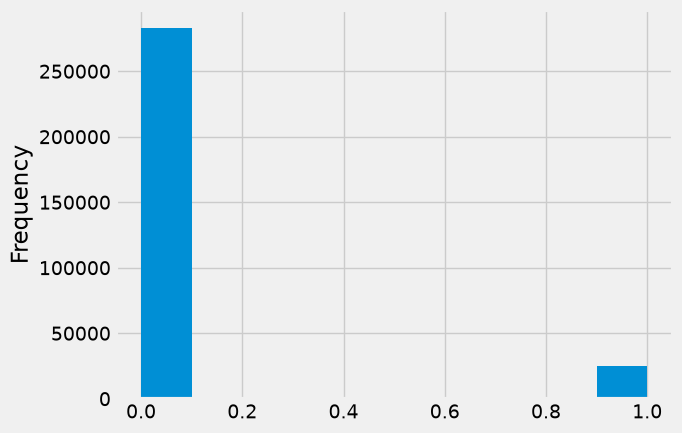

In [144]:
app_train['TARGET'].astype(int).plot.hist();

From this information, we see this is an [_imbalanced class problem_](http://www.chioka.in/class-imbalance-problem/). There are far more loans that were repaid on time than loans that were not repaid. Once we get into more sophisticated machine learning models, we can [weight the classes](http://xgboost.readthedocs.io/en/latest/parameter.html) by their representation in the data to reflect this imbalance. 

## Examine Missing Values

Next we can look at the number and percentage of missing values in each column. 

In [145]:
# Function to calculate missing values by column# Funct 
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        
        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [146]:
# Missing values statistics
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


When it comes time to build our machine learning models, we will have to fill in these missing values (known as imputation). In later work, we will use models such as XGBoost that can [handle missing values with no need for imputation](https://stats.stackexchange.com/questions/235489/xgboost-can-handle-missing-data-in-the-forecasting-phase). Another option would be to drop columns with a high percentage of missing values, although it is impossible to know ahead of time if these columns will be helpful to our model. Therefore, we will keep all of the columns for now.

## Column Types

Let's look at the number of columns of each data type. `int64` and `float64` are numeric variables ([which can be either discrete or continuous](https://stats.stackexchange.com/questions/206/what-is-the-difference-between-discrete-data-and-continuous-data)). `object` columns contain strings and are  [categorical features.](http://support.minitab.com/en-us/minitab-express/1/help-and-how-to/modeling-statistics/regression/supporting-topics/basics/what-are-categorical-discrete-and-continuous-variables/) . 

In [147]:
# Number of each type of column
app_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

Let's now look at the number of unique entries in each of the `object` (categorical) columns.

In [148]:
# Number of unique classes in each object column
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

Most of the categorical variables have a relatively small number of unique entries. We will need to find a way to deal with these categorical variables! 

## Encoding Categorical Variables

Before we go any further, we need to deal with pesky categorical variables.  A machine learning model unfortunately cannot deal with categorical variables (except for some models such as [LightGBM](http://lightgbm.readthedocs.io/en/latest/Features.html)). Therefore, we have to find a way to encode (represent) these variables as numbers before handing them off to the model. There are two main ways to carry out this process:

* Label encoding: assign each unique category in a categorical variable with an integer. No new columns are created. An example is shown below

![image](https://raw.githubusercontent.com/WillKoehrsen/Machine-Learning-Projects/master/label_encoding.png)

* One-hot encoding: create a new column for each unique category in a categorical variable. Each observation recieves a 1 in the column for its corresponding category and a 0 in all other new columns. 

![image](https://raw.githubusercontent.com/WillKoehrsen/Machine-Learning-Projects/master/one_hot_encoding.png)

The problem with label encoding is that it gives the categories an arbitrary ordering. The value assigned to each of the categories is random and does not reflect any inherent aspect of the category. In the example above, programmer recieves a 4 and data scientist a 1, but if we did the same process again, the labels could be reversed or completely different. The actual assignment of the integers is arbitrary. Therefore, when we perform label encoding, the model might use the relative value of the feature (for example programmer = 4 and data scientist = 1) to assign weights which is not what we want. If we only have two unique values for a categorical variable (such as Male/Female), then label encoding is fine, but for more than 2 unique categories, one-hot encoding is the safe option.

There is some debate about the relative merits of these approaches, and some models can deal with label encoded categorical variables with no issues. [Here is a good Stack Overflow discussion](https://datascience.stackexchange.com/questions/9443/when-to-use-one-hot-encoding-vs-labelencoder-vs-dictvectorizor). I think (and this is just a personal opinion) for categorical variables with many classes, one-hot encoding is the safest approach because it does not impose arbitrary values to categories. The only downside to one-hot encoding is that the number of features (dimensions of the data) can explode with categorical variables with many categories. To deal with this, we can perform one-hot encoding followed by [PCA](http://www.cs.otago.ac.nz/cosc453/student_tutorials/principal_components.pdf) or other [dimensionality reduction methods](https://www.analyticsvidhya.com/blog/2015/07/dimension-reduction-methods/) to reduce the number of dimensions (while still trying to preserve information). 

In this notebook, we will use Label Encoding for any categorical variables with only 2 categories and One-Hot Encoding for any categorical variables with more than 2 categories. This process may need to change as we get further into the project, but for now, we will see where this gets us. (We will also not use any dimensionality reduction in this notebook but will explore in future iterations).

### Label Encoding and One-Hot Encoding

Let's implement the policy described above: for any categorical variable (`dtype == object`) with 2 unique categories, we will use label encoding, and for any categorical variable with more than 2 unique categories, we will use one-hot encoding. 

For label encoding, we use the Scikit-Learn `LabelEncoder` and for one-hot encoding, the pandas `get_dummies(df)` function.

In [149]:
# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

0 columns were label encoded.


In [150]:
# one-hot encoding of categorical variables
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 246)
Testing Features shape:  (48744, 242)


### Aligning Training and Testing Data

There need to be the same features (columns) in both the training and testing data. One-hot encoding has created more columns in the training data because there were some categorical variables with categories not represented in the testing data. To remove the columns in the training data that are not in the testing data, we need to `align` the dataframes. First we extract the target column from the training data (because this is not in the testing data but we need to keep this information). When we do the align, we must make sure to set `axis = 1` to align the dataframes based on the columns and not on the rows!

In [151]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 242)


The training and testing datasets now have the same features which is required for machine learning. The number of features has grown significantly due to one-hot encoding. At some point we probably will want to try [dimensionality reduction (removing features that are not relevant)](https://en.wikipedia.org/wiki/Dimensionality_reduction) to reduce the size of the datasets.

## Back to Exploratory Data Analysis

### Anomalies

One problem we always want to be on the lookout for when doing EDA is anomalies within the data. These may be due to mis-typed numbers, errors in measuring equipment, or they could be valid but extreme measurements. One way to support anomalies quantitatively is by looking at the statistics of a column using the `describe` method. The numbers in the `DAYS_BIRTH` column are negative because they are recorded relative to the current loan application. To see these stats in years, we can mutliple by -1 and divide by the number of days in a year:



In [152]:
(app_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

Those ages look reasonable. There are no outliers for the age on either the high or low end. How about the days of employment? 

In [153]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

That doesn't look right! The maximum value (besides being positive) is about 1000 years! 

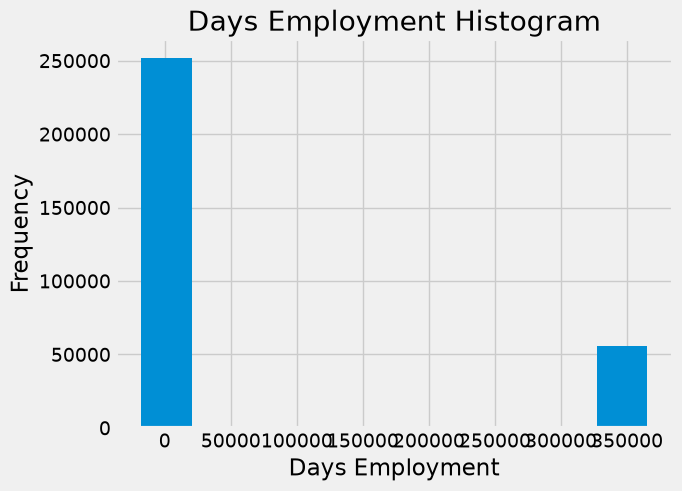

In [154]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

Just out of curiousity, let's subset the anomalous clients and see if they tend to have higher or low rates of default than the rest of the clients.

In [155]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


Well that is extremely interesting! It turns out that the anomalies have a lower rate of default. 

Handling the anomalies depends on the exact situation, with no set rules. One of the safest approaches is just to set the anomalies to a missing value and then have them filled in (using Imputation) before machine learning. In this case, since all the anomalies have the exact same value, we want to fill them in with the same value in case all of these loans share something in common. The anomalous values seem to have some importance, so we want to tell the machine learning model if we did in fact fill in these values. As a solution, we will fill in the anomalous values with not a number (`np.nan`) and then create a new boolean column indicating whether or not the value was anomalous.



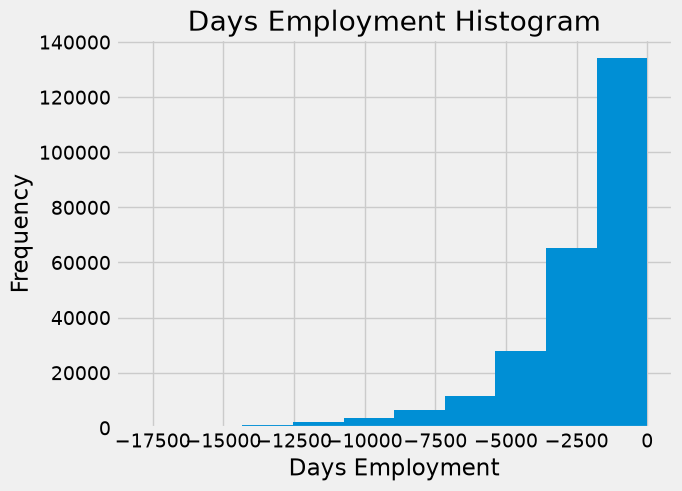

In [156]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'] = app_train['DAYS_EMPLOYED'].replace({365243: np.nan})

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

The distribution looks to be much more in line with what we would expect, and we also have created a new column to tell the model that these values were originally anomalous (becuase we will have to fill in the nans with some value, probably the median of the column). The other columns with `DAYS` in the dataframe look to be about what we expect with no obvious outliers. 

As an extremely important note, anything we do to the training data we also have to do to the testing data. Let's make sure to create the new column and fill in the existing column with `np.nan` in the testing data.

In [157]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"] = app_test["DAYS_EMPLOYED"].replace({365243: np.nan})

print('There are %d anomalies in the test data out of %d entries' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

There are 9274 anomalies in the test data out of 48744 entries


### Correlations

Now that we have dealt with the categorical variables and the outliers, let's continue with the EDA. One way to try and understand the data is by looking for correlations between the features and the target. We can calculate the Pearson correlation coefficient between every variable and the target using the `.corr` dataframe method.

The correlation coefficient is not the greatest method to represent "relevance" of a feature, but it does give us an idea of possible relationships within the data. Some [general interpretations of the absolute value of the correlation coefficent](http://www.statstutor.ac.uk/resources/uploaded/pearsons.pdf) are:


* .00-.19 “very weak”
*  .20-.39 “weak”
*  .40-.59 “moderate”
*  .60-.79 “strong”
* .80-1.0 “very strong”


In [158]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_EMPLOYED                                        0.074958
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

Let's take a look at some of more significant correlations: the `DAYS_BIRTH` is the most positive correlation. (except for `TARGET` because the correlation of a variable with itself is always 1!) Looking at the documentation, `DAYS_BIRTH` is the age in days of the client at the time of the loan in negative days (for whatever reason!). The correlation is positive, but the value of this feature is actually negative, meaning that as the client gets older, they are less likely to default on their loan (ie the target == 0). That's a little confusing, so we will take the absolute value of the feature and then the correlation will be negative.

### Effect of Age on Repayment

In [159]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07823930830982488)

As the client gets older, there is a negative linear relationship with the target meaning that as clients get older, they tend to repay their loans on time more often. 

Let's start looking at this variable. First, we can make a histogram of the age. We will put the x axis in years to make the plot a little more understandable.

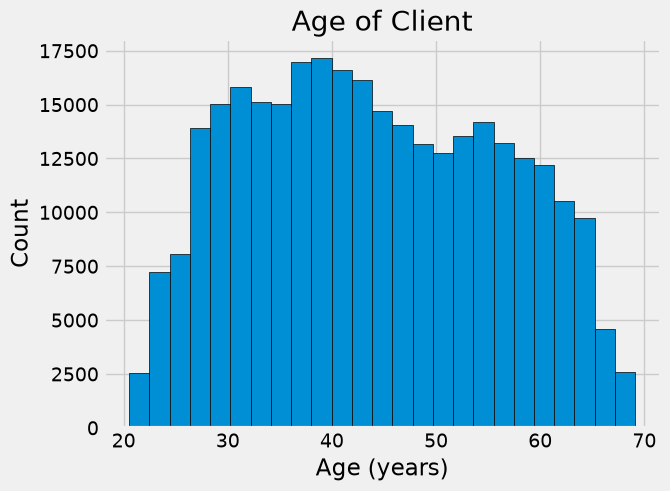

In [160]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count');

By itself, the distribution of age does not tell us much other than that there are no outliers as all the ages are reasonable. To visualize the effect of the age on the target, we will next make a [kernel density estimation plot](https://en.wikipedia.org/wiki/Kernel_density_estimation) (KDE) colored by the value of the target. A [kernel density estimate plot shows the distribution of a single variable](https://chemicalstatistician.wordpress.com/2013/06/09/exploratory-data-analysis-kernel-density-estimation-in-r-on-ozone-pollution-data-in-new-york-and-ozonopolis/) and can be thought of as a smoothed histogram (it is created by computing a kernel, usually a Gaussian, at each data point and then averaging all the individual kernels to develop a single smooth curve). We will use the seaborn `kdeplot` for this graph.

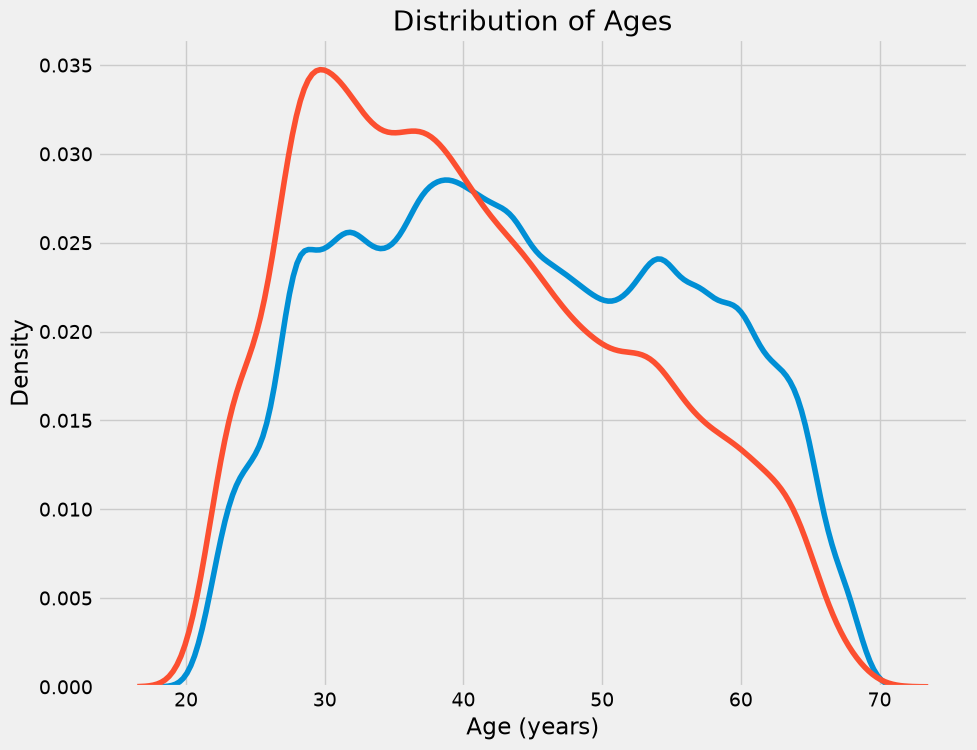

In [161]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');

The target == 1 curve skews towards the younger end of the range. Although this is not a significant correlation (-0.07 correlation coefficient), this variable is likely going to be useful in a machine learning model because it does affect the target. Let's look at this relationship in another way: average failure to repay loans by age bracket. 

To make this graph, first we `cut` the age category into bins of 5 years each. Then, for each bin, we calculate the average value of the target, which tells us the ratio of loans that were not repaid in each age category.

In [162]:
# Age information into a separate dataframe
age_data = app_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [163]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


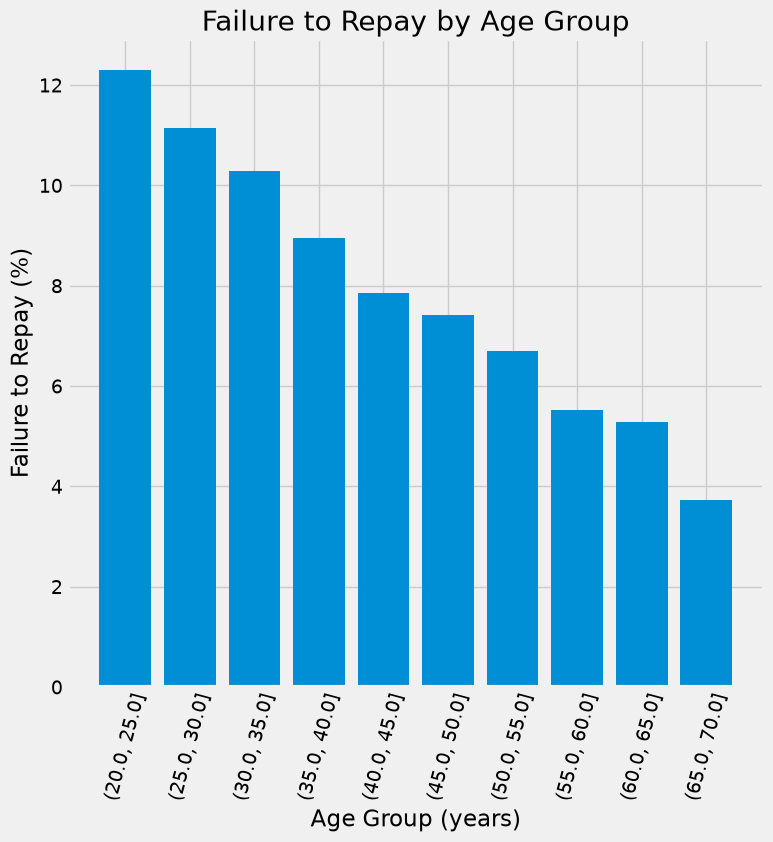

In [164]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group');

There is a clear trend: younger applicants are more likely to not repay the loan! The rate of failure to repay is above 10% for the youngest three age groups and beolow 5% for the oldest age group.

This is information that could be directly used by the bank: because younger clients are less likely to repay the loan, maybe they should be provided with more guidance or financial planning tips. This does not mean the bank should discriminate against younger clients, but it would be smart to take precautionary measures to help younger clients pay on time.

### Exterior Sources

The 3 variables with the strongest negative correlations with the target are `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`.
According to the documentation, these features represent a "normalized score from external data source". I'm not sure what this exactly means, but it may be a cumulative sort of credit rating made using numerous sources of data. 

Let's take a look at these variables.

First, we can show the correlations of the `EXT_SOURCE` features with the target and with each other.

In [165]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


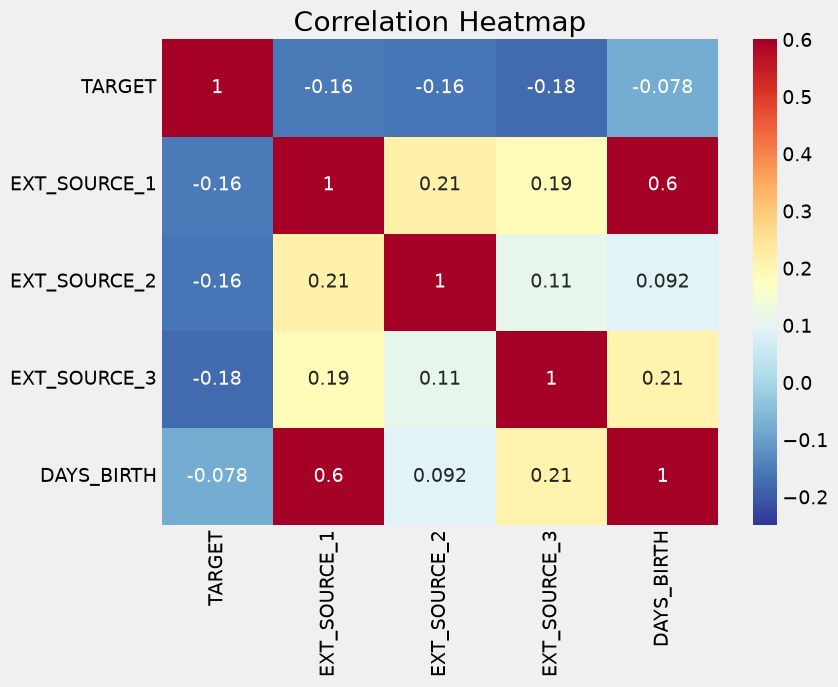

In [166]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

All three `EXT_SOURCE` featureshave negative correlations with the target, indicating that as the value of the `EXT_SOURCE` increases, the client is more likely to repay the loan. We can also see that `DAYS_BIRTH` is positively correlated with `EXT_SOURCE_1` indicating that maybe one of the factors in this score is the client age.

Next we can look at the distribution of each of these features colored by the value of the target. This will let us visualize the effect of this variable on the target.

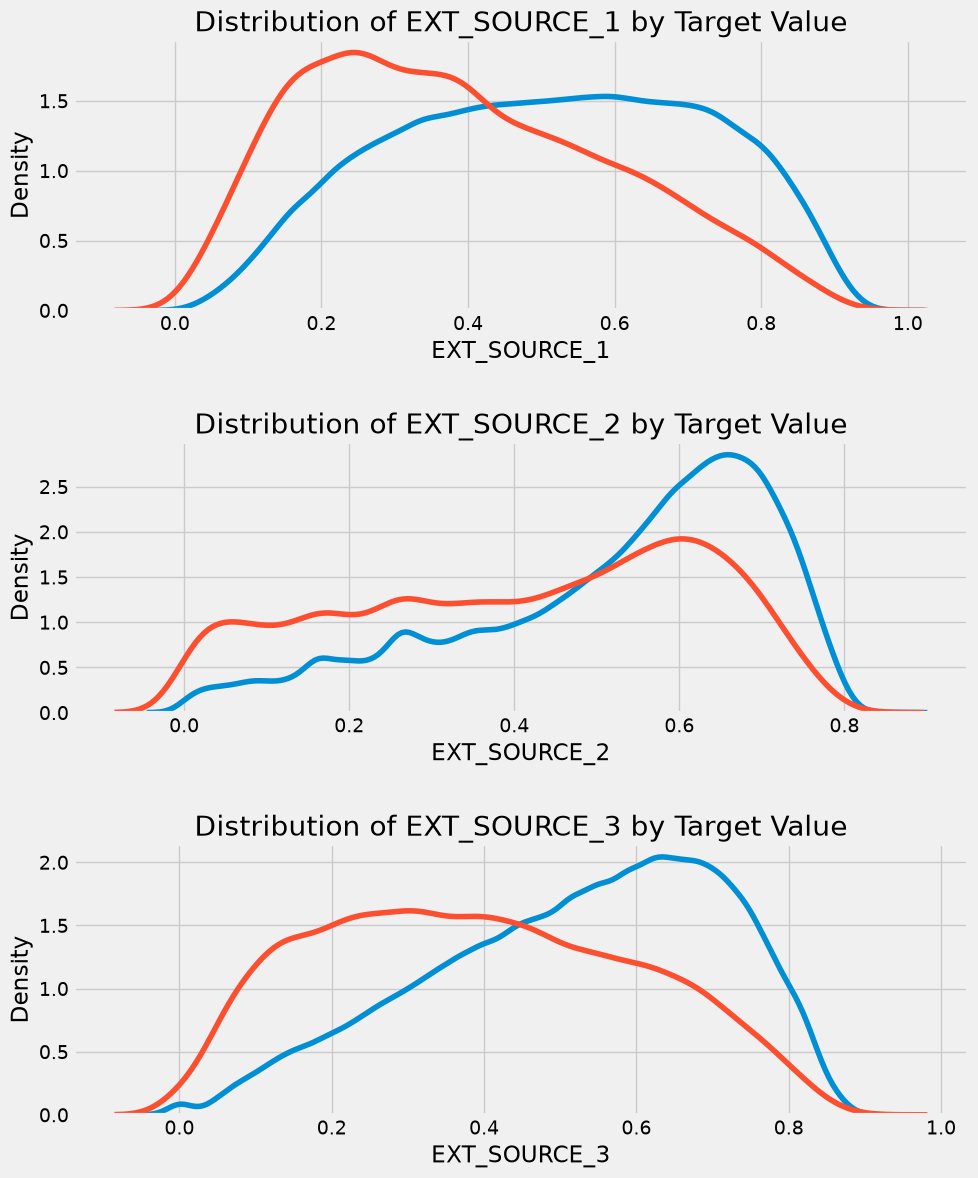

In [167]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)
    

`EXT_SOURCE_3` displays the greatest difference between the values of the target. We can clearly see that this feature has some relationship to the likelihood of an applicant to repay a loan. The relationship is not very strong (in fact they are all [considered very weak](http://www.statstutor.ac.uk/resources/uploaded/pearsons.pdf), but these variables will still be useful for a machine learning model to predict whether or not an applicant will repay a loan on time.

## Pairs Plot

As a final exploratory plot, we can make a pairs plot of the `EXT_SOURCE` variables and the `DAYS_BIRTH` variable. The [Pairs Plot](https://towardsdatascience.com/visualizing-data-with-pair-plots-in-python-f228cf529166) is a great exploration tool because it lets us see relationships between multiple pairs of variables as well as distributions of single variables. Here we are using the seaborn visualization library and the PairGrid function to create a Pairs Plot with scatterplots on the upper triangle, histograms on the diagonal, and 2D kernel density plots and correlation coefficients on the lower triangle.

If you don't understand this code, that's all right! Plotting in Python can be overly complex, and for anything beyond the simplest graphs, I usually find an existing implementation and adapt the code (don't repeat yourself)! 

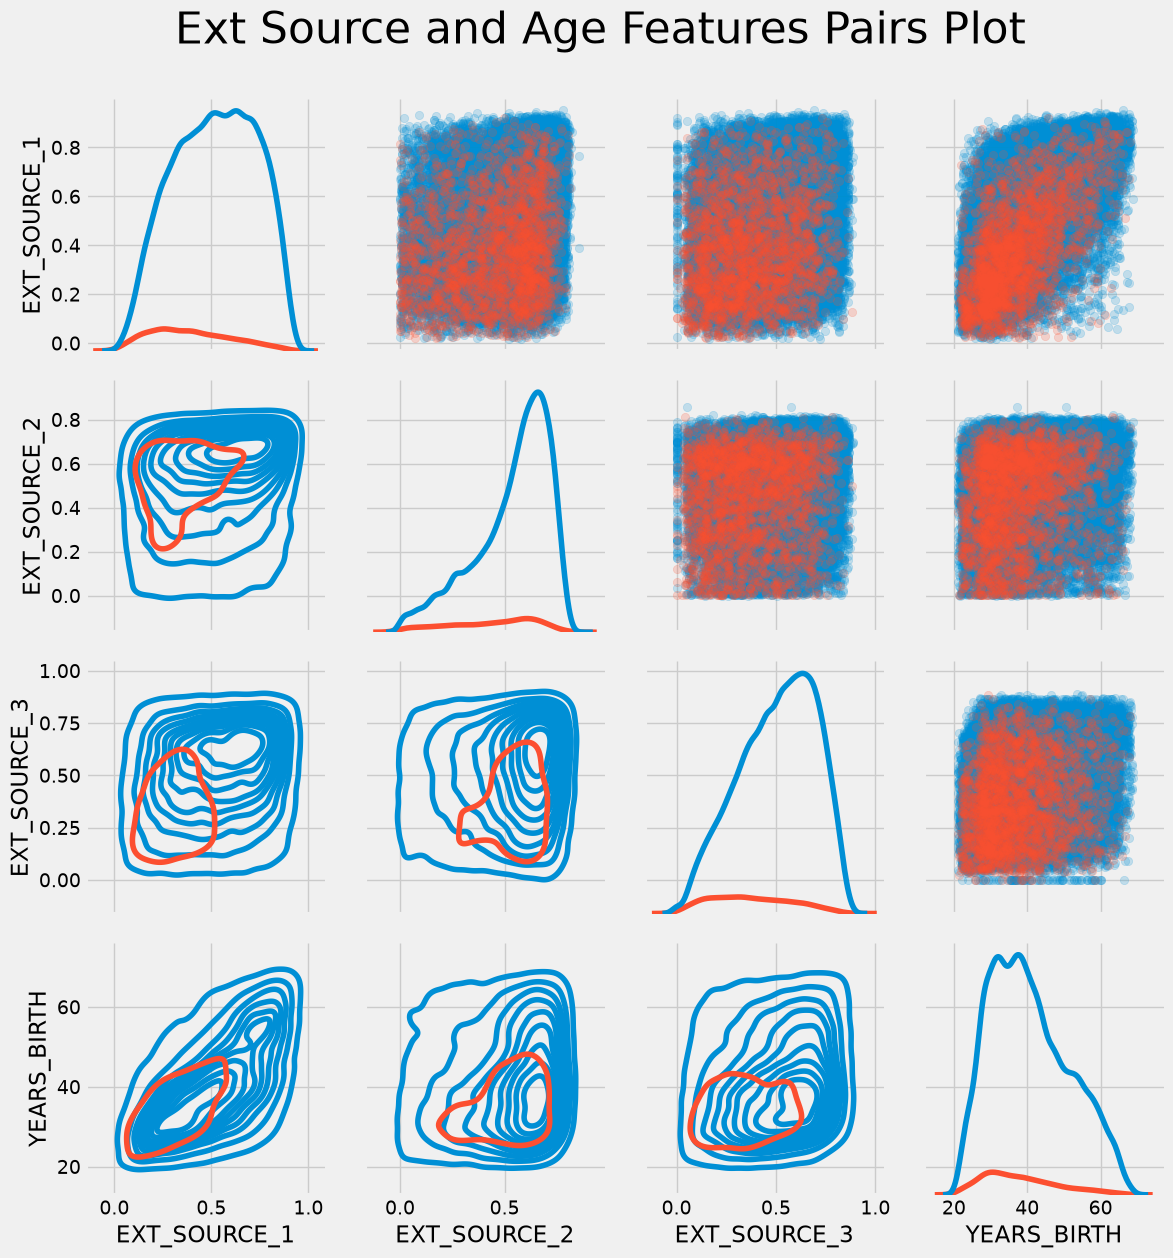

In [168]:
# Copy the data for plotting
plot_data = ext_data.drop(columns = ['DAYS_BIRTH']).copy()

# Add in the age of the client in years
plot_data['YEARS_BIRTH'] = age_data['YEARS_BIRTH']

# Drop na values and limit to first 100000 rows
plot_data = plot_data.dropna().loc[:100000, :]

# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate("r = {:.2f}".format(r),
                xy=(.2, .8), xycoords=ax.transAxes,
                size = 20)

# Create the pairgrid object
grid = sns.PairGrid(data = plot_data, height = 3, diag_sharey=False,
                    hue = 'TARGET', 
                    vars = [x for x in list(plot_data.columns) if x != 'TARGET'])

# Upper is a scatter plot
grid.map_upper(plt.scatter, alpha = 0.2)

# Diagonal is a histogram
grid.map_diag(sns.kdeplot)

# Bottom is density plot
grid.map_lower(sns.kdeplot, cmap = plt.cm.OrRd_r);

plt.suptitle('Ext Source and Age Features Pairs Plot', size = 32, y = 1.05);

In this plot, the red indicates loans that were not repaid and the blue are loans that are paid. We can see the different relationships within the data. There does appear to be a moderate positive linear relationship between the `EXT_SOURCE_1` and the `DAYS_BIRTH` (or equivalently `YEARS_BIRTH`), indicating that this feature may take into account the age of the client. 

# Feature Engineering

Kaggle competitions are won by feature engineering: those win are those who can create the most useful features out of the data. (This is true for the most part as the winning models, at least for structured data, all tend to be variants on [gradient boosting](http://blog.kaggle.com/2017/01/23/a-kaggle-master-explains-gradient-boosting/)). This represents one of the patterns in machine learning: feature engineering has a greater return on investment than model building and hyperparameter tuning. [This is a great article on the subject)](https://www.featurelabs.com/blog/secret-to-data-science-success/). As Andrew Ng is fond of saying: "applied machine learning is basically feature engineering." 

While choosing the right model and optimal settings are important, the model can only learn from the data it is given. Making sure this data is as relevant to the task as possible is the job of the data scientist (and maybe some [automated tools](https://docs.featuretools.com/getting_started/install.html) to help us out).

Feature engineering refers to a geneal process and can involve both feature construction: adding new features from the existing data, and feature selection: choosing only the most important features or other methods of dimensionality reduction. There are many techniques we can use to both create features and select features.

We will do a lot of feature engineering when we start using the other data sources, but in this notebook we will try only two simple feature construction methods: 

* Polynomial features
* Domain knowledge features


## Polynomial Features

One simple feature construction method is called [polynomial features](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html). In this method, we make features that are powers of existing features as well as interaction terms between existing features. For example, we can create variables `EXT_SOURCE_1^2` and `EXT_SOURCE_2^2` and also variables such as `EXT_SOURCE_1` x `EXT_SOURCE_2`, `EXT_SOURCE_1` x `EXT_SOURCE_2^2`, `EXT_SOURCE_1^2` x   `EXT_SOURCE_2^2`, and so on. These features that are a combination of multiple individual variables are called [interaction terms](https://en.wikipedia.org/wiki/Interaction_(statistics) because they  capture the interactions between variables. In other words, while two variables by themselves  may not have a strong influence on the target, combining them together into a single interaction variable might show a relationship with the target. [Interaction terms are commonly used in statistical models](https://www.theanalysisfactor.com/interpreting-interactions-in-regression/) to capture the effects of multiple variables, but I do not see them used as often in machine learning. Nonetheless, we can try out a few to see if they might help our model to predict whether or not a client will repay a loan. 

Jake VanderPlas writes about [polynomial features in his excellent book Python for Data Science](https://jakevdp.github.io/PythonDataScienceHandbook/05.04-feature-engineering.html) for those who want more information.

In the following code, we create polynomial features using the `EXT_SOURCE` variables and the `DAYS_BIRTH` variable. [Scikit-Learn has a useful class called `PolynomialFeatures`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) that creates the polynomials and the interaction terms up to a specified degree. We can use a degree of 3 to see the results (when we are creating polynomial features, we want to avoid using too high of a degree, both because the number of features scales exponentially with the degree, and because we can run into [problems with overfitting](http://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html#sphx-glr-auto-examples-model-selection-plot-underfitting-overfitting-py)). 

In [169]:
# Make a new dataframe for polynomial features
poly_features = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'TARGET']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]

# imputer for handling missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'median')

poly_target = poly_features['TARGET']

poly_features = poly_features.drop(columns = ['TARGET'])

# Need to impute missing values
poly_features = imputer.fit_transform(poly_features)
poly_features_test = imputer.transform(poly_features_test)

from sklearn.preprocessing import PolynomialFeatures
                                  
# Create the polynomial object with specified degree
poly_transformer = PolynomialFeatures(degree = 3)

In [170]:
# Train the polynomial features
poly_transformer.fit(poly_features)

# Transform the features
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Polynomial Features shape: ', poly_features.shape)

Polynomial Features shape:  (307511, 35)


This creates a considerable number of new features. To get the names we have to use the polynomial features `get_feature_names` method.

In [171]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH'])[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 DAYS_BIRTH',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 DAYS_BIRTH', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 DAYS_BIRTH', 'DAYS_BIRTH^2'], dtype=object)

There are 35 features with individual features raised to powers up to degree 3 and interaction terms. Now, we can see whether any of these new features are correlated with the target.

In [172]:
# Create a dataframe of the features 
poly_features = pd.DataFrame(poly_features, 
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                           'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Add in the target
poly_features['TARGET'] = poly_target

# Find the correlations with the target
poly_corrs = poly_features.corr()['TARGET'].sort_values()

# Display most negative and most positive
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.193939
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.189605
EXT_SOURCE_2 EXT_SOURCE_3 DAYS_BIRTH     -0.181283
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.176428
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.172282
EXT_SOURCE_1 EXT_SOURCE_2                -0.166625
EXT_SOURCE_1 EXT_SOURCE_3                -0.164065
EXT_SOURCE_2                             -0.160295
EXT_SOURCE_2 DAYS_BIRTH                  -0.156873
EXT_SOURCE_1 EXT_SOURCE_2^2              -0.156867
Name: TARGET, dtype: float64
DAYS_BIRTH     -0.078239
DAYS_BIRTH^2   -0.076672
DAYS_BIRTH^3   -0.074273
TARGET          1.000000
1                    NaN
Name: TARGET, dtype: float64


Several of the new variables have a greater (in terms of absolute magnitude) correlation with the target than the original features. When we build machine learning models, we can try with and without these features to determine if they actually help the model learn. 

We will add these features to a copy of the training and testing data and then evaluate models with and without the features. Many times in machine learning, the only way to know if an approach will work is to try it out! 

In [173]:
# Put test features into dataframe
poly_features_test = pd.DataFrame(poly_features_test, 
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2', 
                                                                                'EXT_SOURCE_3', 'DAYS_BIRTH']))

# Merge polynomial features into training dataframe
poly_features['SK_ID_CURR'] = app_train['SK_ID_CURR']
app_train_poly = app_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Merge polnomial features into testing dataframe
poly_features_test['SK_ID_CURR'] = app_test['SK_ID_CURR']
app_test_poly = app_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Align the dataframes
app_train_poly, app_test_poly = app_train_poly.align(app_test_poly, join = 'inner', axis = 1)

# Print out the new shapes
print('Training data with polynomial features shape: ', app_train_poly.shape)
print('Testing data with polynomial features shape:  ', app_test_poly.shape)

Training data with polynomial features shape:  (307511, 278)
Testing data with polynomial features shape:   (48744, 278)


## Domain Knowledge Features

Maybe it's not entirely correct to call this "domain knowledge" because I'm not a credit expert, but perhaps we could call this "attempts at applying limited financial knowledge". In this frame of mind, we can make a couple features that attempt to capture what we think may be important for telling whether a client will default on a loan. Here I'm going to use five features that were inspired by [this script](https://www.kaggle.com/jsaguiar/updated-0-792-lb-lightgbm-with-simple-features) by Aguiar:

* `CREDIT_INCOME_PERCENT`: the percentage of the credit amount relative to a client's income
* `ANNUITY_INCOME_PERCENT`: the percentage of the loan annuity relative to a client's income
* `CREDIT_TERM`:  the length of the payment in months (since the annuity is the monthly amount due
* `DAYS_EMPLOYED_PERCENT`: the percentage of the days employed relative to the client's age

Again, thanks to Aguiar and [his great script](https://www.kaggle.com/jsaguiar/updated-0-792-lb-lightgbm-with-simple-features) for exploring these features.



In [174]:
app_train_domain = app_train.copy()
app_test_domain = app_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

In [175]:
app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYED'] / app_test_domain['DAYS_BIRTH']

#### Visualize New Variables

We should explore these __domain knowledge__ variables visually in a graph. For all of these, we will make the same KDE plot colored by the value of the `TARGET`.

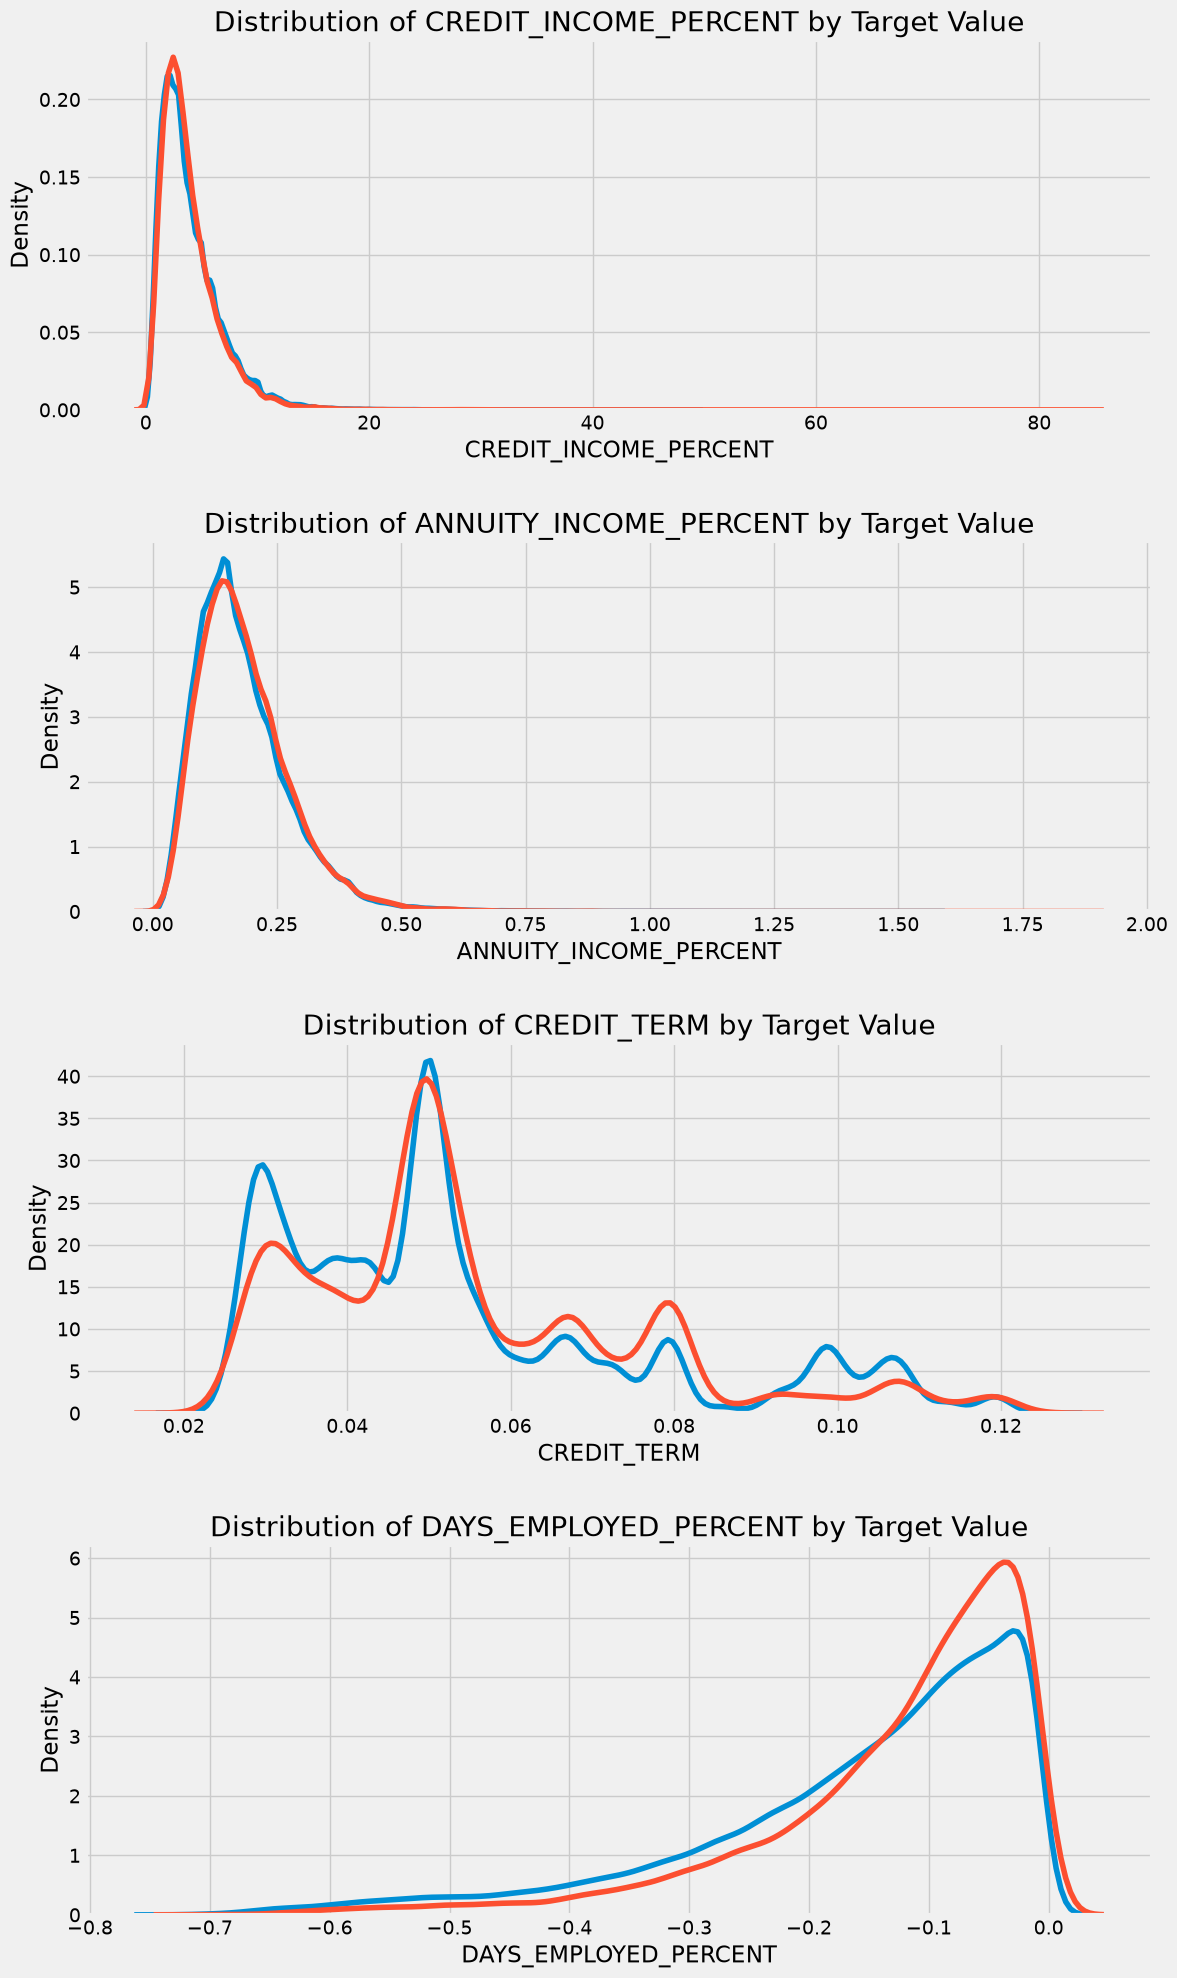

In [176]:
plt.figure(figsize = (12, 20))
# iterate through the new features
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    
    # create a new subplot for each source
    plt.subplot(4, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 0, feature], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train_domain.loc[app_train_domain['TARGET'] == 1, feature], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % feature)
    plt.xlabel('%s' % feature); plt.ylabel('Density');
    
plt.tight_layout(h_pad = 2.5)

It's hard to say ahead of time if these new features will be useful. The only way to tell for sure is to try them out! 

# Baseline

For a naive baseline, we could guess the same value for all examples on the testing set.  We are asked to predict the probability of not repaying the loan, so if we are entirely unsure, we would guess 0.5 for all observations on the test set. This  will get us a Reciever Operating Characteristic Area Under the Curve (AUC ROC) of 0.5 in the competition ([random guessing on a classification task will score a 0.5](https://stats.stackexchange.com/questions/266387/can-auc-roc-be-between-0-0-5)).

Since we already know what score we are going to get, we don't really need to make a naive baseline guess. Let's use a slightly more sophisticated model for our actual baseline: Logistic Regression.

## Logistic Regression Implementation

Here I will focus on implementing the model rather than explaining the details, but for those who want to learn more about the theory of machine learning algorithms, I recommend both [An Introduction to Statistical Learning](http://www-bcf.usc.edu/~gareth/ISL/) and [Hands-On Machine Learning with Scikit-Learn and TensorFlow](http://shop.oreilly.com/product/0636920052289.do). Both of these books present the theory and also the code needed to make the models (in R and Python respectively). They both teach with the mindset that the best way to learn is by doing, and they are very effective! 

To get a baseline, we will use all of the features after encoding the categorical variables. We will preprocess the data by filling in the missing values (imputation) and normalizing the range of the features (feature scaling). The following code performs both of these preprocessing steps.

In [177]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

# Drop the target from the training data
if 'TARGET' in app_train:
    train = app_train.drop(columns = ['TARGET'])
else:
    train = app_train.copy()
    
# Feature names
features = list(train.columns)

# Copy of the testing data
test = app_test.copy()

# Median imputation of missing values
imputer = SimpleImputer(strategy = 'median')

# Scale each feature to 0-1
scaler = MinMaxScaler(feature_range = (0, 1))

# Fit on the training data
imputer.fit(train)

# Transform both training and testing data
train = imputer.transform(train)
test = imputer.transform(app_test)

# Repeat with the scaler
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

print('Training data shape: ', train.shape)
print('Testing data shape: ', test.shape)

Training data shape:  (307511, 243)
Testing data shape:  (48744, 243)


We will use [`LogisticRegression`from Scikit-Learn](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for our first model. The only change we will make from the default model settings is to lower the [regularization parameter](http://scikit-learn.org/stable/modules/linear_model.html#logistic-regression), C, which controls the amount of overfitting (a lower value should decrease overfitting). This will get us slightly better results than the default `LogisticRegression`, but it still will set a low bar for any future models.

Here we use the familiar Scikit-Learn modeling syntax: we first create the model, then we train the model using `.fit` and then we make predictions on the testing data using `.predict_proba` (remember that we want probabilities and not a 0 or 1).

In [178]:
from sklearn.linear_model import LogisticRegression

# Make the model with the specified regularization parameter
log_reg = LogisticRegression(C = 0.0001)

# Train on the training data
log_reg.fit(train, train_labels)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.0001
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default 

Now that the model has been trained, we can use it to make predictions. We want to predict the probabilities of not paying a loan, so we use the model `predict.proba` method. This returns an m x 2 array where m is the number of observations. The first column is the probability of the target being 0 and the second column is the probability of the target being 1 (so for a single row, the two columns must sum to 1). We want the probability the loan is not repaid, so we will select the second column.

The following code makes the predictions and selects the correct column.

In [179]:
# Make predictions
# Make sure to select the second column only
log_reg_pred = log_reg.predict_proba(test)[:, 1]

The predictions must be in the format shown in the `sample_submission.csv` file, where there are only two columns: `SK_ID_CURR` and `TARGET`. We will create a dataframe in this format from the test set and the predictions called `submit`. 

In [180]:
# Submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = log_reg_pred

submit.head()

,SK_ID_CURR,TARGET
0,100001,0.079936
1,100005,0.140783
2,100013,0.081478
3,100028,0.082196
4,100038,0.130321


The predictions represent a probability between 0 and 1 that the loan will not be repaid. If we were using these predictions to classify applicants, we could set a probability threshold for determining that a loan is risky. 

In [181]:
# Save the submission to a csv file
submit.to_csv('log_reg_baseline.csv', index = False)

The submission has now been saved to the virtual environment in which our notebook is running. To access the submission, at the end of the notebook, we will hit the blue Commit & Run button at the upper right of the kernel. This runs the entire notebook and then lets us download any files that are created during the run. 

Once we run the notebook, the files created are available in the Versions tab under the Output sub-tab. From here, the submission files can be submitted to the competition or downloaded. Since there are several models in this notebook, there will be multiple output files. 

__The logistic regression baseline should score around 0.671 when submitted.__

## Improved Model: Random Forest

To try and beat the poor performance of our baseline, we can update the algorithm. Let's try using a Random Forest on the same training data to see how that affects performance. The Random Forest is a much more powerful model especially when we use hundreds of trees. We will use 100 trees in the random forest.

In [182]:
from sklearn.ensemble import RandomForestClassifier

# Make the random forest classifier
random_forest = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

In [183]:
# Train on the training data
random_forest.fit(train, train_labels)

# Extract feature importances
feature_importance_values = random_forest.feature_importances_
feature_importances = pd.DataFrame({'feature': features, 'importance': feature_importance_values})

# Make predictions on the test data
predictions = random_forest.predict_proba(test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.8s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished


In [184]:
# Make a submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline.csv', index = False)

These predictions will also be available when we run the entire notebook. 

__This model should score around 0.678 when submitted.__

### Make Predictions using Engineered Features

The only way to see if the Polynomial Features and Domain knowledge improved the model is to train a test a model on these features! We can then compare the submission performance to that for the model without these features to gauge the effect of our feature engineering.

In [185]:
poly_features_names = list(app_train_poly.columns)

# Impute the polynomial features
imputer = SimpleImputer(strategy = 'median')

poly_features = imputer.fit_transform(app_train_poly)
poly_features_test = imputer.transform(app_test_poly)

# Scale the polynomial features
scaler = MinMaxScaler(feature_range = (0, 1))

poly_features = scaler.fit_transform(poly_features)
poly_features_test = scaler.transform(poly_features_test)

random_forest_poly = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

In [186]:
# Train on the training data
random_forest_poly.fit(poly_features, train_labels)

# Make predictions on the test data
predictions = random_forest_poly.predict_proba(poly_features_test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   14.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [187]:
# Make a submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline_engineered.csv', index = False)

This model scored 0.678 when submitted to the competition, exactly the same as that without the engineered features. Given these results, it does not appear that our feature construction helped in this case. 

#### Testing Domain Features

Now we can test the domain features we made by hand.

In [188]:
app_train_domain = app_train_domain.drop(columns = 'TARGET')

domain_features_names = list(app_train_domain.columns)

# Impute the domainnomial features
imputer = SimpleImputer(strategy = 'median')

domain_features = imputer.fit_transform(app_train_domain)
domain_features_test = imputer.transform(app_test_domain)

# Scale the domainnomial features
scaler = MinMaxScaler(feature_range = (0, 1))

domain_features = scaler.fit_transform(domain_features)
domain_features_test = scaler.transform(domain_features_test)

random_forest_domain = RandomForestClassifier(n_estimators = 100, random_state = 50, verbose = 1, n_jobs = -1)

# Train on the training data
random_forest_domain.fit(domain_features, train_labels)

# Extract feature importances
feature_importance_values_domain = random_forest_domain.feature_importances_
feature_importances_domain = pd.DataFrame({'feature': domain_features_names, 'importance': feature_importance_values_domain})

# Make predictions on the test data
predictions = random_forest_domain.predict_proba(domain_features_test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.5s


KeyboardInterrupt: 

In [ ]:
# Make a submission dataframe
submit = app_test[['SK_ID_CURR']]
submit['TARGET'] = predictions

# Save the submission dataframe
submit.to_csv('random_forest_baseline_domain.csv', index = False)

This scores 0.679 when submitted which probably shows that the engineered features do not help in this model (however they do help in the Gradient Boosting Model at the end of the notebook).

In later notebooks, we will do more [feature engineering](https://docs.featuretools.com/index.html) by using the information from the other data sources. From experience, this will definitely help our model! 

## Model Interpretation: Feature Importances

As a simple method to see which variables are the most relevant, we can look at the feature importances of the random forest. Given the correlations we saw in the exploratory data analysis, we should expect that the most important features are the `EXT_SOURCE` and the `DAYS_BIRTH`. We may use these feature importances as a method of dimensionality reduction in future work.

In [ ]:
def plot_feature_importances(df):
    """
    Plot importances returned by a model. This can work with any measure of
    feature importance provided that higher importance is better. 
    
    Args:
        df (dataframe): feature importances. Must have the features in a column
        called `features` and the importances in a column called `importance
        
    Returns:
        shows a plot of the 15 most importance features
        
        df (dataframe): feature importances sorted by importance (highest to lowest) 
        with a column for normalized importance
        """
    
    # Sort features according to importance
    df = df.sort_values('importance', ascending = False).reset_index()
    
    # Normalize the feature importances to add up to one
    df['importance_normalized'] = df['importance'] / df['importance'].sum()

    # Make a horizontal bar chart of feature importances
    plt.figure(figsize = (10, 6))
    ax = plt.subplot()
    
    # Need to reverse the index to plot most important on top
    ax.barh(list(reversed(list(df.index[:15]))), 
            df['importance_normalized'].head(15), 
            align = 'center', edgecolor = 'k')
    
    # Set the yticks and labels
    ax.set_yticks(list(reversed(list(df.index[:15]))))
    ax.set_yticklabels(df['feature'].head(15))
    
    # Plot labeling
    plt.xlabel('Normalized Importance'); plt.title('Feature Importances')
    plt.show()
    
    return df

In [ ]:
# Show the feature importances for the default features
feature_importances_sorted = plot_feature_importances(feature_importances)

As expected, the most important features are those dealing with `EXT_SOURCE` and `DAYS_BIRTH`. We see that there are only a handful of features with a significant importance to the model, which suggests we may be able to drop many of the features without a decrease in performance (and we may even see an increase in performance.) Feature importances are not the most sophisticated method to interpret a model or perform dimensionality reduction, but they let us start to understand what factors our model takes into account when it makes predictions. 

In [ ]:
feature_importances_domain_sorted = plot_feature_importances(feature_importances_domain)

We see that all four of our hand-engineered features made it into the top 15 most important! This should give us confidence that our domain knowledge was at least partially on track.

# Conclusions

In this notebook, we saw how to get started with a Kaggle machine learning competition. We first made sure to understand the data, our task, and the metric by which our submissions will be judged. Then, we performed a fairly simple EDA to try and identify relationships, trends, or anomalies that may help our modeling. Along the way, we performed necessary preprocessing steps such as encoding categorical variables, imputing missing values, and scaling features to a range. Then, we constructed new features out of the existing data to see if doing so could help our model. 

Once the data exploration, data preparation, and feature engineering was complete, we implemented a baseline model upon which we hope to improve. Then we built a second slightly more complicated model to beat our first score. We also carried out an experiment to determine the effect of adding the engineering variables. 

We followed the general outline of a [machine learning project](https://towardsdatascience.com/a-complete-machine-learning-walk-through-in-python-part-one-c62152f39420): 

1.  Understand the problem and the data
2. Data cleaning and formatting (this was mostly done for us)
3. Exploratory Data Analysis
4. Baseline model
5.  Improved model
6. Model interpretation (just a little)

Machine learning competitions do differ slightly from typical data science problems in that we are concerned only with achieving the best performance on a single metric and do not care about the interpretation. However, by attempting to understand how our models make decisions, we can try to improve them or examine the mistakes in order to correct the errors. In future notebooks we will look at incorporating more sources of data, building more complex models (by following the code of others), and improving our scores. 

I hope this notebook was able to get you up and running in this machine learning competition and that you are now ready to go out on your own - with help from the community - and start working on some great problems! 

__Running the notebook__: now that we are at the end of the notebook, you can hit the blue Commit & Run button to execute all the code at once. After the run is complete (this should take about 10 minutes), you can then access the files that were created by going to the versions tab and then the output sub-tab. The submission files can be directly submitted to the competition from this tab or they can be downloaded to a local machine and saved. The final part is to share the share the notebook: go to the settings tab and change the visibility to Public. This allows the entire world to see your work! 

### Follow-up Notebooks

For those looking to keep working on this problem, I have a series of follow-up notebooks:

* [Manual Feature Engineering Part One](https://www.kaggle.com/willkoehrsen/introduction-to-manual-feature-engineering)
* [Manual Feature Engineering Part Two](https://www.kaggle.com/willkoehrsen/introduction-to-manual-feature-engineering-p2)
* [Introduction to Automated Feature Engineering](https://www.kaggle.com/willkoehrsen/automated-feature-engineering-basics)
* [Advanced Automated Feature Engineering](https://www.kaggle.com/willkoehrsen/tuning-automated-feature-engineering-exploratory)
* [Feature Selection](https://www.kaggle.com/willkoehrsen/introduction-to-feature-selection)
* [Intro to Model Tuning: Grid and Random Search](https://www.kaggle.com/willkoehrsen/intro-to-model-tuning-grid-and-random-search)

As always, I welcome feedback and constructive criticism. I write for Towards Data Science at https://medium.com/@williamkoehrsen/ and can be reached on Twitter at https://twitter.com/koehrsen_will

Will


# Just for Fun: Light Gradient Boosting Machine

Now (if you want, this part is entirely optional) we can step off the deep end and use a real machine learning model: the [gradient boosting machine](https://machinelearningmastery.com/gentle-introduction-gradient-boosting-algorithm-machine-learning/) using the [LightGBM library](http://lightgbm.readthedocs.io/en/latest/Quick-Start.html)! The Gradient Boosting Machine is currently the leading model for learning on structured datasets (especially on Kaggle) and we will probably need some form of this model to do well in the competition. Don't worry, even if this code looks intimidating, it's just a series of small steps that build up to a complete model. I added this code just to show what may be in store for this project, and because it gets us a slightly better score on the leaderboard. In future notebooks we will see how to work with more advanced models (which mostly means adapting existing code to make it work better), feature engineering, and feature selection. See you in the next notebook!  

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import gc

def model(features, test_features, encoding = 'ohe', n_folds = 5):
    
    """Train and test a light gradient boosting model using
    cross validation. 
    
    Parameters
    --------
        features (pd.DataFrame): 
            dataframe of training features to use 
            for training a model. Must include the TARGET column.
        test_features (pd.DataFrame): 
            dataframe of testing features to use
            for making predictions with the model. 
        encoding (str, default = 'ohe'): 
            method for encoding categorical variables. Either 'ohe' for one-hot encoding or 'le' for integer label encoding
            n_folds (int, default = 5): number of folds to use for cross validation
        
    Return
    --------
        submission (pd.DataFrame): 
            dataframe with `SK_ID_CURR` and `TARGET` probabilities
            predicted by the model.
        feature_importances (pd.DataFrame): 
            dataframe with the feature importances from the model.
        valid_metrics (pd.DataFrame): 
            dataframe with training and validation metrics (ROC AUC) for each fold and overall.
        
    """
    
    # Extract the ids
    train_ids = features['SK_ID_CURR']
    test_ids = test_features['SK_ID_CURR']
    
    # Extract the labels for training
    labels = features['TARGET']
    
    # Remove the ids and target
    features = features.drop(columns = ['SK_ID_CURR', 'TARGET'])
    test_features = test_features.drop(columns = ['SK_ID_CURR'])
    
    
    # One Hot Encoding
    if encoding == 'ohe':
        features = pd.get_dummies(features)
        test_features = pd.get_dummies(test_features)
        
        # Align the dataframes by the columns
        features, test_features = features.align(test_features, join = 'inner', axis = 1)
        
        # No categorical indices to record
        cat_indices = 'auto'
    
    # Integer label encoding
    elif encoding == 'le':
        
        # Create a label encoder
        label_encoder = LabelEncoder()
        
        # List for storing categorical indices
        cat_indices = []
        
        # Iterate through each column
        for i, col in enumerate(features):
            if features[col].dtype == 'object':
                # Map the categorical features to integers
                features[col] = label_encoder.fit_transform(np.array(features[col].astype(str)).reshape((-1,)))
                test_features[col] = label_encoder.transform(np.array(test_features[col].astype(str)).reshape((-1,)))

                # Record the categorical indices
                cat_indices.append(i)
    
    # Catch error if label encoding scheme is not valid
    else:
        raise ValueError("Encoding must be either 'ohe' or 'le'")
        
    print('Training Data Shape: ', features.shape)
    print('Testing Data Shape: ', test_features.shape)
    
    # Extract feature names
    feature_names = list(features.columns)
    
    # Convert to np arrays
    features = np.array(features)
    test_features = np.array(test_features)
    
    # Create the kfold object
    k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 50)
    
    # Empty array for feature importances
    feature_importance_values = np.zeros(len(feature_names))
    
    # Empty array for test predictions
    test_predictions = np.zeros(test_features.shape[0])
    
    # Empty array for out of fold validation predictions
    out_of_fold = np.zeros(features.shape[0])
    
    # Lists for recording validation and training scores
    valid_scores = []
    train_scores = []
    
    # Iterate through each fold
    for train_indices, valid_indices in k_fold.split(features):
        
        # Training data for the fold
        train_features, train_labels = features[train_indices], labels[train_indices]
        # Validation data for the fold
        valid_features, valid_labels = features[valid_indices], labels[valid_indices]
        
        # Create the model
        model = lgb.LGBMClassifier(n_estimators=10000, objective = 'binary', 
                                   class_weight = 'balanced', learning_rate = 0.05, 
                                   reg_alpha = 0.1, reg_lambda = 0.1, 
                                   subsample = 0.8, n_jobs = -1, random_state = 50)
        
        # Train the model
        model.fit(train_features, train_labels, eval_metric = 'auc',
                  eval_set = [(valid_features, valid_labels), (train_features, train_labels)],
                  eval_names = ['valid', 'train'], categorical_feature = cat_indices,
                  callbacks = [lgb.early_stopping(100), lgb.log_evaluation(200)])
        
        # Record the best iteration
        best_iteration = model.best_iteration_
        
        # Record the feature importances
        feature_importance_values += model.feature_importances_ / k_fold.n_splits
        
        # Make predictions
        test_predictions += model.predict_proba(test_features, num_iteration = best_iteration)[:, 1] / k_fold.n_splits
        
        # Record the out of fold predictions
        out_of_fold[valid_indices] = model.predict_proba(valid_features, num_iteration = best_iteration)[:, 1]
        
        # Record the best score
        valid_score = model.best_score_['valid']['auc']
        train_score = model.best_score_['train']['auc']
        
        valid_scores.append(valid_score)
        train_scores.append(train_score)
        
        # Clean up memory
        gc.enable()
        del model, train_features, valid_features
        gc.collect()
        
    # Make the submission dataframe
    submission = pd.DataFrame({'SK_ID_CURR': test_ids, 'TARGET': test_predictions})
    
    # Make the feature importance dataframe
    feature_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importance_values})
    
    # Overall validation score
    valid_auc = roc_auc_score(labels, out_of_fold)
    
    # Add the overall scores to the metrics
    valid_scores.append(valid_auc)
    train_scores.append(np.mean(train_scores))
    
    # Needed for creating dataframe of validation scores
    fold_names = list(range(n_folds))
    fold_names.append('overall')
    
    # Dataframe of validation scores
    metrics = pd.DataFrame({'fold': fold_names,
                            'train': train_scores,
                            'valid': valid_scores}) 
    
    return submission, feature_importances, metrics

In [ ]:
submission, fi, metrics = model(app_train, app_test)
print('Baseline metrics')
print(metrics)

In [ ]:
fi_sorted = plot_feature_importances(fi)

In [ ]:
submission.to_csv('baseline_lgb.csv', index = False)

This submission should score about 0.735 on the leaderboard. We will certainly best that in future work! 

In [ ]:
app_train_domain['TARGET'] = train_labels

# Test the domain knolwedge features
submission_domain, fi_domain, metrics_domain = model(app_train_domain, app_test_domain)
print('Baseline with domain knowledge features metrics')
print(metrics_domain)

In [ ]:
fi_sorted = plot_feature_importances(fi_domain)

Again, we see tha some of our features made it into the most important. Going forward, we will need to think about whatother domain knowledge features may be useful for this problem (or we should consult someone who knows more about the financial industry! 

In [ ]:
submission_domain.to_csv('baseline_lgb_domain_features.csv', index = False)

This model scores about 0.754 when submitted to the public leaderboard indicating that the domain features do improve the performance! [Feature engineering](https://en.wikipedia.org/wiki/Feature_engineering) is going to be a critical part of this competition (as it is for all machine learning problems)!

# Comparaison de modèles : LightGBM vs XGBoost vs CatBoost

Nous ajoutons ici **XGBoost** et **CatBoost** aux côtés de LightGBM et nous les
comparons selon **exactement le même protocole** que la fonction `model()`
plus haut, afin que la comparaison soit équitable :

- **Mêmes features** : encodage one-hot des variables catégorielles, identique pour les trois modèles.
- **Validation croisée K-Fold** : 5 plis, `shuffle=True`, `random_state=50`.
- **Prédictions out-of-fold (OOF)** : chaque ligne d'entraînement est prédite par un modèle qui ne l'a jamais vue → estimation honnête de la performance.
- **Métrique ROC AUC** calculée de façon identique avec `sklearn.metrics.roc_auc_score`.
- **Déséquilibre des classes** géré par pondération « balanced » (équivalent dans chaque librairie).
- **Prédiction finale** = moyenne des 5 modèles sur le jeu de test.

> Prérequis (déjà installés dans ce projet) : `uv add xgboost catboost`.
>
> Note : le code utilise les API **actuelles** (LightGBM ≥ 4.7 avec *callbacks*,
> XGBoost ≥ 2.0, CatBoost ≥ 1.2), compatibles avec l'environnement du projet.

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
import gc


def run_cv_model(model_name, features, test_features, n_folds=5):
    """Entraine et evalue un modele de boosting en validation croisee K-Fold.

    Protocole IDENTIQUE pour tous les modeles (comparaison equitable) :
      - encodage one-hot commun a tous les modeles
      - K-Fold (n_folds plis, shuffle=True, random_state=50)
      - predictions out-of-fold + moyenne des plis sur le test
      - metrique ROC AUC calculee de facon identique via sklearn

    Parametres
    ----------
    model_name : {'lgb', 'xgb', 'cat'}
        Modele a entrainer.
    features : pd.DataFrame
        Donnees d'entrainement, doivent contenir les colonnes SK_ID_CURR et TARGET.
    test_features : pd.DataFrame
        Donnees de test, doivent contenir la colonne SK_ID_CURR.

    Retourne
    --------
    submission : pd.DataFrame  (SK_ID_CURR, TARGET)
    feature_importances : pd.DataFrame  (feature, importance)
    metrics : pd.DataFrame  (fold, train, valid)  -- AUC par pli + ligne 'overall'
    """

    # --- Identifiants et labels ---
    train_ids = features['SK_ID_CURR']
    test_ids = test_features['SK_ID_CURR']

    labels = np.array(features['TARGET']).astype(int)

    features = features.drop(columns=['SK_ID_CURR', 'TARGET'])
    test_features = test_features.drop(columns=['SK_ID_CURR'])

    # --- Encodage one-hot commun a tous les modeles ---
    features = pd.get_dummies(features)
    test_features = pd.get_dummies(test_features)
    features, test_features = features.align(test_features, join='inner', axis=1)

    feature_names = list(features.columns)
    features = np.array(features)
    test_features = np.array(test_features)

    # --- Gestion du desequilibre : ratio negatifs / positifs (pour XGBoost) ---
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    scale_pos_weight = n_neg / n_pos

    # --- K-Fold (memes parametres pour tous) ---
    k_fold = KFold(n_splits=n_folds, shuffle=True, random_state=50)

    feature_importance_values = np.zeros(len(feature_names))
    test_predictions = np.zeros(test_features.shape[0])
    out_of_fold = np.zeros(features.shape[0])

    valid_scores = []
    train_scores = []

    for train_idx, valid_idx in k_fold.split(features):
        train_features, train_labels = features[train_idx], labels[train_idx]
        valid_features, valid_labels = features[valid_idx], labels[valid_idx]

        # ---- Construction + entrainement selon le modele choisi ----
        if model_name == 'lgb':
            import lightgbm as lgb
            model = lgb.LGBMClassifier(
                n_estimators=10000, objective='binary', class_weight='balanced',
                learning_rate=0.05, reg_alpha=0.1, reg_lambda=0.1,
                subsample=0.8, n_jobs=-1, random_state=50, verbose=-1)
            model.fit(
                train_features, train_labels, eval_metric='auc',
                eval_set=[(valid_features, valid_labels)],
                callbacks=[lgb.early_stopping(100, verbose=False),
                           lgb.log_evaluation(0)])
            best_iteration = model.best_iteration_
            importances = model.feature_importances_
            valid_preds = model.predict_proba(valid_features, num_iteration=best_iteration)[:, 1]
            train_preds = model.predict_proba(train_features, num_iteration=best_iteration)[:, 1]
            fold_test_preds = model.predict_proba(test_features, num_iteration=best_iteration)[:, 1]

        elif model_name == 'xgb':
            from xgboost import XGBClassifier
            model = XGBClassifier(
                n_estimators=10000, learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
                scale_pos_weight=scale_pos_weight, objective='binary:logistic',
                eval_metric='auc', early_stopping_rounds=100, tree_method='hist',
                n_jobs=-1, random_state=50)
            model.fit(
                train_features, train_labels,
                eval_set=[(valid_features, valid_labels)], verbose=False)
            best_iteration = model.best_iteration
            rng = (0, best_iteration + 1)
            importances = model.feature_importances_
            valid_preds = model.predict_proba(valid_features, iteration_range=rng)[:, 1]
            train_preds = model.predict_proba(train_features, iteration_range=rng)[:, 1]
            fold_test_preds = model.predict_proba(test_features, iteration_range=rng)[:, 1]

        elif model_name == 'cat':
            from catboost import CatBoostClassifier
            model = CatBoostClassifier(
                iterations=10000, learning_rate=0.05, l2_leaf_reg=3.0,
                subsample=0.8, bootstrap_type='Bernoulli',
                loss_function='Logloss', eval_metric='AUC',
                auto_class_weights='Balanced', random_seed=50,
                thread_count=-1, allow_writing_files=False)
            model.fit(
                train_features, train_labels,
                eval_set=[(valid_features, valid_labels)],
                early_stopping_rounds=100, use_best_model=True, verbose=False)
            best_iteration = model.get_best_iteration()
            importances = model.get_feature_importance()
            valid_preds = model.predict_proba(valid_features)[:, 1]
            train_preds = model.predict_proba(train_features)[:, 1]
            fold_test_preds = model.predict_proba(test_features)[:, 1]

        else:
            raise ValueError("model_name doit etre 'lgb', 'xgb' ou 'cat'")

        # ---- Enregistrement des resultats du pli ----
        out_of_fold[valid_idx] = valid_preds
        test_predictions += fold_test_preds / k_fold.n_splits
        feature_importance_values += importances / k_fold.n_splits

        valid_scores.append(roc_auc_score(valid_labels, valid_preds))
        train_scores.append(roc_auc_score(train_labels, train_preds))

        print('%s | pli termine - iteration optimale : %s' % (model_name, best_iteration))

        gc.enable()
        del model, train_features, valid_features
        gc.collect()

    # --- Assemblage des sorties ---
    submission = pd.DataFrame({'SK_ID_CURR': test_ids, 'TARGET': test_predictions})
    feature_importances = pd.DataFrame({'feature': feature_names,
                                        'importance': feature_importance_values})

    valid_auc = roc_auc_score(labels, out_of_fold)   # AUC out-of-fold global
    valid_scores.append(valid_auc)
    train_scores.append(np.mean(train_scores))

    fold_names = list(range(n_folds)) + ['overall']
    metrics = pd.DataFrame({'fold': fold_names,
                            'train': train_scores,
                            'valid': valid_scores})
    return submission, feature_importances, metrics

In [ ]:
# Entrainer les trois modeles avec le meme protocole (features de base)
sub_lgb, fi_lgb, metrics_lgb = run_cv_model('lgb', app_train, app_test)
print('LightGBM :\n', metrics_lgb, '\n')

sub_xgb, fi_xgb, metrics_xgb = run_cv_model('xgb', app_train, app_test)
print('XGBoost :\n', metrics_xgb, '\n')

sub_cat, fi_cat, metrics_cat = run_cv_model('cat', app_train, app_test)
print('CatBoost :\n', metrics_cat, '\n')

# Sauvegarder les soumissions (format Kaggle)
sub_lgb.to_csv('baseline_lgb.csv', index=False)
sub_xgb.to_csv('baseline_xgb.csv', index=False)
sub_cat.to_csv('baseline_catboost.csv', index=False)

In [ ]:
# Tableau recapitulatif des scores ROC AUC (ligne 'overall' de chaque modele)
def overall(metrics, col):
    return metrics.loc[metrics['fold'] == 'overall', col].values[0]

comparison = pd.DataFrame({
    'model': ['LightGBM', 'XGBoost', 'CatBoost'],
    'train_auc': [overall(metrics_lgb, 'train'),
                  overall(metrics_xgb, 'train'),
                  overall(metrics_cat, 'train')],
    'valid_auc_oof': [overall(metrics_lgb, 'valid'),
                      overall(metrics_xgb, 'valid'),
                      overall(metrics_cat, 'valid')],
})

# Ecart train - validation : indicateur de surapprentissage (plus c'est petit, mieux c'est)
comparison['overfit_gap'] = comparison['train_auc'] - comparison['valid_auc_oof']
comparison = comparison.sort_values('valid_auc_oof', ascending=False).reset_index(drop=True)
comparison

In [ ]:
# Graphique comparatif des AUC de validation (out-of-fold)
plt.style.use('fivethirtyeight')
plt.figure(figsize=(9, 5))

order = comparison.sort_values('valid_auc_oof')
plt.barh(order['model'], order['valid_auc_oof'], edgecolor='k')

# Ajuster l'axe autour des valeurs pour mieux voir les ecarts
lo = min(0.70, order['valid_auc_oof'].min() - 0.01)
plt.xlim(lo, order['valid_auc_oof'].max() + 0.01)
plt.xlabel('ROC AUC (validation out-of-fold)')
plt.title('Comparaison des modeles - meme protocole (K-Fold 5, ROC AUC)')

for y, v in enumerate(order['valid_auc_oof']):
    plt.text(v, y, ' %.4f' % v, va='center')

plt.tight_layout()
plt.show()

## (Optionnel) Comparaison avec les features "domain knowledge"

On peut relancer exactement le même comparatif sur les données enrichies des
4 features métier (`app_train_domain` / `app_test_domain`) construites plus haut,
pour mesurer leur apport sur chaque modèle. Cette cellule est plus longue à
exécuter (3 modèles × 5 plis).

> Nécessite d'avoir exécuté les cellules qui créent `app_train_domain` et
> `app_test_domain` (section *Domain Knowledge Features*).

In [ ]:
# S'assurer que la cible est bien presente dans le jeu domain
if 'TARGET' not in app_train_domain.columns:
    app_train_domain['TARGET'] = train_labels

sub_lgb_d, fi_lgb_d, metrics_lgb_d = run_cv_model('lgb', app_train_domain, app_test_domain)
sub_xgb_d, fi_xgb_d, metrics_xgb_d = run_cv_model('xgb', app_train_domain, app_test_domain)
sub_cat_d, fi_cat_d, metrics_cat_d = run_cv_model('cat', app_train_domain, app_test_domain)

comparison_domain = pd.DataFrame({
    'model': ['LightGBM', 'XGBoost', 'CatBoost'],
    'valid_auc_base': comparison.set_index('model').loc[
        ['LightGBM', 'XGBoost', 'CatBoost'], 'valid_auc_oof'].values,
    'valid_auc_domain': [overall(metrics_lgb_d, 'valid'),
                         overall(metrics_xgb_d, 'valid'),
                         overall(metrics_cat_d, 'valid')],
})
comparison_domain['gain'] = (comparison_domain['valid_auc_domain']
                             - comparison_domain['valid_auc_base'])
comparison_domain = comparison_domain.sort_values('valid_auc_domain', ascending=False)
comparison_domain

# Interprétabilité : analyse SHAP

Les `feature_importances_` d'un arbre disent *quelles* variables comptent, mais
pas *comment* ni *dans quel sens*. **SHAP** (SHapley Additive exPlanations) va
plus loin : il décompose **chaque prédiction** en contributions additives de
chaque feature, avec une base théorique (les valeurs de Shapley de la théorie
des jeux).

- **Interprétation globale** : quelles features pèsent le plus sur l'ensemble des clients, et dans quel sens.
- **Interprétation locale** : pourquoi *ce* client précis est jugé risqué ou non.

Sur les modèles à base d'arbres (LightGBM/XGBoost/CatBoost), `TreeExplainer`
calcule les valeurs SHAP de façon **exacte et rapide**.

Convention de lecture : une valeur SHAP **positive** pousse la prédiction vers
la classe **1 (défaut de paiement)**, une valeur **négative** vers la classe
**0 (remboursement)**.

> Prérequis (déjà installé dans ce projet) : `uv add shap`.

In [ ]:
# --- Entrainer un modele LightGBM dedie a l'interpretation ---
import shap
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# 1) Memes features que les modeles compares (one-hot + alignement train/test)
feat_df = pd.get_dummies(app_train.drop(columns=['SK_ID_CURR', 'TARGET']))
test_df = pd.get_dummies(app_test.drop(columns=['SK_ID_CURR']))
feat_df, test_df = feat_df.align(test_df, join='inner', axis=1)

feature_names_shap = list(feat_df.columns)
y_shap = app_train['TARGET'].astype(int).values

# LightGBM refuse les noms de colonnes avec caracteres speciaux (ex. "Trade: type 7")
# -> on entraine sur un tableau numpy, et on redonne les noms a SHAP ensuite.
X_all = feat_df.to_numpy()

# 2) Split simple + early stopping pour obtenir un modele unique a expliquer
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_shap, test_size=0.2, random_state=50, stratify=y_shap)

shap_model = lgb.LGBMClassifier(
    n_estimators=10000, objective='binary', class_weight='balanced',
    learning_rate=0.05, reg_alpha=0.1, reg_lambda=0.1, subsample=0.8,
    n_jobs=-1, random_state=50, verbose=-1)
shap_model.fit(X_tr, y_tr, eval_metric='auc', eval_set=[(X_val, y_val)],
               callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
print('Modele entraine - iteration optimale :', shap_model.best_iteration_)

In [ ]:
# 3) Calcul des valeurs SHAP sur un echantillon representatif
#    (le beeswarm sur 300k points serait illisible et lent -> on echantillonne)
X_sample = feat_df.sample(2000, random_state=1)   # DataFrame => noms conserves

explainer = shap.TreeExplainer(shap_model)
shap_exp = explainer(X_sample)

# En binaire, certaines versions renvoient les 2 classes : on garde la positive
if np.asarray(shap_exp.values).ndim == 3:
    shap_exp = shap_exp[:, :, 1]

sv2d = np.asarray(shap_exp.values)
print('Valeurs SHAP calculees :', sv2d.shape)

In [ ]:
# 4) Importance globale : moyenne des |valeurs SHAP| par feature
shap.summary_plot(sv2d, X_sample, plot_type='bar', max_display=15, show=True)

In [ ]:
# 5) Beeswarm : sens ET amplitude de l'effet de chaque feature
#    rouge = valeur elevee de la feature | bleu = valeur basse
#    SHAP > 0 -> pousse vers le defaut (1) | SHAP < 0 -> vers le remboursement (0)
shap.plots.beeswarm(shap_exp, max_display=15)

In [ ]:
# 6) Dependence plot : comment la valeur d'EXT_SOURCE_3 influence sa contribution
#    On voit la relation decroissante : plus le score externe est haut,
#    plus la contribution SHAP est negative (moins de risque de defaut).
shap.plots.scatter(shap_exp[:, "EXT_SOURCE_3"])

In [ ]:
# 7) Explication LOCALE : pourquoi CE client est-il juge risque ?
#    On prend, dans l'echantillon, le client avec la plus forte proba de defaut.
proba_sample = shap_model.predict_proba(X_sample.to_numpy())[:, 1]
i_risque = int(np.argmax(proba_sample))
print('Client le plus risque de l\'echantillon - proba de defaut estimee : %.3f'
      % proba_sample[i_risque])

# Le waterfall montre comment on part de la valeur de base (moyenne) et comment
# chaque feature ajoute/retranche pour arriver a la prediction de ce client.
shap.plots.waterfall(shap_exp[i_risque], max_display=15)

### Ce que l'analyse SHAP nous apprend

- **`EXT_SOURCE_1/2/3` dominent** : ce sont de loin les variables les plus
  influentes, et l'effet est cohérent (score externe élevé → contribution
  négative → moins de risque de défaut). Cela confirme quantitativement l'EDA.
- **Montants et durée du crédit** (`AMT_GOODS_PRICE`, `AMT_CREDIT`,
  `AMT_ANNUITY`) et **variables temporelles** (`DAYS_EMPLOYED`, `DAYS_BIRTH`)
  forment le second groupe de facteurs.
- L'explication **locale** (waterfall) est précieuse côté métier : pour un
  dossier refusé, on peut dire *pourquoi* (ex. score externe faible + ancienneté
  courte), ce qui est important pour la transparence et la réglementation du crédit.

**Prochaine étape logique** : maintenant que SHAP a validé quelles features
portent le signal, on peut revenir au **choix du seuil de décision** (recall /
coût métier) en toute connaissance de cause.

# Suivi d'expériences avec MLflow

C'est le cœur de l'approche **MLOps** : au lieu de noter les scores à la main,
on **journalise automatiquement** chaque entraînement — ses paramètres, ses
métriques et ses artefacts — pour pouvoir comparer et reproduire les runs.

Pour chaque modèle on enregistre :
- **Paramètres** : type de modèle, hyperparamètres, configuration de la validation croisée.
- **Métriques** : ROC AUC out-of-fold, ROC AUC train, écart de surapprentissage, AUC par pli.
- **Artefacts** : fichier de soumission, importances des features (CSV + graphique).

On utilise un **backend SQLite** (`sqlite:///mlflow.db`) — recommandé par MLflow
et nécessaire pour le *model registry*. Les artefacts sont stockés dans `mlruns/`.

> Prérequis (déjà installé) : `uv add mlflow`.

In [ ]:
import mlflow

# Backend de tracking local (SQLite) + nom de l'experience
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("home_credit_default_risk")

print("Tracking URI :", mlflow.get_tracking_uri())

In [ ]:
# Hyperparametres communs (traces pour la reproductibilite)
COMMON_PARAMS = {
    "n_estimators_max": 10000,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "early_stopping_rounds": 100,
    "n_folds": 5,
    "cv": "KFold(shuffle=True, random_state=50)",
    "class_imbalance": "balanced",
    "encoding": "one-hot",
}


def run_and_log(model_name, features, test_features, dataset_tag="base"):
    """Entraine un modele via run_cv_model et journalise tout dans MLflow."""
    with mlflow.start_run(run_name=f"{model_name}_{dataset_tag}"):
        # 1) Parametres
        mlflow.log_param("model", model_name)
        mlflow.log_param("dataset", dataset_tag)
        mlflow.log_params(COMMON_PARAMS)

        # 2) Entrainement + evaluation (meme protocole que la comparaison)
        submission, fi, metrics = run_cv_model(model_name, features, test_features)

        # 3) Metriques
        overall = metrics[metrics["fold"] == "overall"].iloc[0]
        mlflow.log_metric("valid_auc_oof", overall["valid"])
        mlflow.log_metric("train_auc", overall["train"])
        mlflow.log_metric("overfit_gap", overall["train"] - overall["valid"])
        for _, row in metrics[metrics["fold"] != "overall"].iterrows():
            mlflow.log_metric("fold_valid_auc", row["valid"], step=int(row["fold"]))

        # 4) Artefacts (log_text / log_figure : pas de fichier local a nettoyer)
        mlflow.log_text(submission.to_csv(index=False),
                        f"submission_{model_name}_{dataset_tag}.csv")
        fi_sorted = fi.sort_values("importance", ascending=False)
        mlflow.log_text(fi_sorted.to_csv(index=False),
                        f"feature_importances_{model_name}_{dataset_tag}.csv")

        top = fi_sorted.head(15).iloc[::-1]
        fig = plt.figure(figsize=(8, 6))
        plt.barh(top["feature"].astype(str), top["importance"], edgecolor="k")
        plt.title(f"Feature importances - {model_name} ({dataset_tag})")
        plt.tight_layout()
        mlflow.log_figure(fig, f"feature_importances_{model_name}_{dataset_tag}.png")
        plt.close(fig)

        print(f"[MLflow] {model_name} ({dataset_tag}) : valid AUC OOF = {overall['valid']:.4f}")
        return submission, fi, metrics

In [ ]:
# Journaliser les trois modeles (un run MLflow chacun)
run_and_log('lgb', app_train, app_test)
run_and_log('xgb', app_train, app_test)
run_and_log('cat', app_train, app_test)

### Comparer les runs

**Interface graphique** — dans un terminal, à la racine du projet :

```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

puis ouvrir http://localhost:5000 : on peut trier les runs par `valid_auc_oof`,
comparer les paramètres, tracer les métriques et télécharger les artefacts.

**Par le code** — on relit directement le tableau des runs :

In [ ]:
# Tableau comparatif des runs enregistres
runs = mlflow.search_runs(experiment_names=["home_credit_default_risk"])
cols = ["tags.mlflow.runName", "params.model", "params.dataset",
        "metrics.valid_auc_oof", "metrics.train_auc", "metrics.overfit_gap"]
runs[cols].sort_values("metrics.valid_auc_oof", ascending=False).reset_index(drop=True)

### Et ensuite ?

- **Features « métier »** : relancer `run_and_log('lgb', app_train_domain, app_test_domain, dataset_tag='domain')` pour comparer, dans MLflow, l'apport des features engineered sur chaque modèle.
- **Model registry** : enregistrer le meilleur modèle (`mlflow.register_model`) pour le versionner et le passer en *Staging* / *Production*.
- **Seuil de décision** : logger aussi le recall / la précision / le coût métier au seuil retenu, en complément du ROC AUC.

# Optimisation des hyperparamètres (GridSearchCV)

Jusqu'ici on utilisait des hyperparamètres fixés à la main. On peut chercher de
meilleures valeurs automatiquement avec **`GridSearchCV`** : on teste toutes les
combinaisons d'une grille, chacune évaluée en validation croisée, et on garde
la meilleure selon le **ROC AUC**.

### Les hyperparamètres clés du gradient boosting (LightGBM)

| Hyperparamètre | Rôle | Effet |
|---|---|---|
| `n_estimators` | nombre d'arbres | ↑ = plus de capacité, mais risque de surapprentissage |
| `learning_rate` | pas d'apprentissage | ↓ = apprentissage plus fin (compense par plus d'arbres) |
| `num_leaves` | nb de feuilles par arbre | **le plus important en LightGBM** : ↑ = arbres plus complexes |
| `max_depth` | profondeur max | limite la complexité / le surapprentissage |
| `reg_alpha` / `reg_lambda` | régularisation L1 / L2 | ↑ = modèle plus simple, moins de surapprentissage |
| `subsample` / `colsample_bytree` | échantillonnage lignes / colonnes | < 1 = plus de robustesse (stochastique) |
| `min_child_samples` | données min par feuille | ↑ = feuilles moins spécifiques |

> ⚠️ **Coût** : un GridSearch teste `nb_combinaisons × nb_folds` modèles. Sur
> 307 000 lignes c'est très long, donc on l'exécute ici sur un **sous-échantillon**
> et une grille modeste. Pour un espace de recherche large, préférer
> `RandomizedSearchCV` ou une optimisation bayésienne (Optuna).

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1) Memes features que les autres modeles (numpy pour eviter le probleme de
#    noms de colonnes avec caracteres speciaux dans LightGBM)
X_gs = pd.get_dummies(app_train.drop(columns=['SK_ID_CURR', 'TARGET']))
Xt_gs = pd.get_dummies(app_test.drop(columns=['SK_ID_CURR']))
X_gs, Xt_gs = X_gs.align(Xt_gs, join='inner', axis=1)
X_gs = X_gs.to_numpy()
y_gs = app_train['TARGET'].astype(int).values

# 2) Sous-echantillon stratifie pour accelerer la recherche
SUBSAMPLE = 50000
rng = np.random.RandomState(50)
idx = rng.choice(len(X_gs), size=min(SUBSAMPLE, len(X_gs)), replace=False)
X_sub, y_sub = X_gs[idx], y_gs[idx]
print('Recherche sur %d lignes' % len(X_sub))

# 3) Estimateur de base + grille d'hyperparametres
estimator = lgb.LGBMClassifier(
    objective='binary', class_weight='balanced', subsample=0.8,
    n_jobs=-1, random_state=50, verbose=-1)

param_grid = {
    'num_leaves': [31, 63],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 400],
}

# 4) Validation croisee stratifiee (garde le meme taux de defaut par pli)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)

grid_search = GridSearchCV(
    estimator, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid_search.fit(X_sub, y_sub)

print('\\nMeilleur ROC AUC (CV) :', round(grid_search.best_score_, 4))
print('Meilleurs hyperparametres :', grid_search.best_params_)

In [ ]:
# Tableau complet des combinaisons testees, classees par score
cv_results = pd.DataFrame(grid_search.cv_results_)
cols = [c for c in cv_results.columns if c.startswith('param_')] + \
       ['mean_test_score', 'std_test_score', 'rank_test_score']
cv_results[cols].sort_values('rank_test_score').reset_index(drop=True)

In [ ]:
# Journaliser le meilleur reglage dans MLflow
with mlflow.start_run(run_name='lgb_gridsearch'):
    mlflow.log_param('model', 'lgb')
    mlflow.log_param('search', 'GridSearchCV')
    mlflow.log_param('subsample_rows', len(X_sub))
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric('best_cv_roc_auc', grid_search.best_score_)
    mlflow.log_text(cv_results[cols].sort_values('rank_test_score').to_csv(index=False),
                    'gridsearch_results.csv')
    print('[MLflow] GridSearch logge - best CV ROC AUC = %.4f' % grid_search.best_score_)

### Interprétation et suite

- `GridSearchCV` a retenu les hyperparamètres qui **maximisent le ROC AUC** en
  validation croisée. Souvent, un `num_leaves` modéré et un `learning_rate` plus
  faible réduisent le surapprentissage.
- Le score de la recherche est calculé sur le **sous-échantillon** : il sera
  généralement un peu **inférieur** au score obtenu ensuite sur les 307 000 lignes.

**Pour utiliser ces hyperparamètres**, on peut les réinjecter dans un
entraînement complet — par exemple en adaptant l'estimateur `lgb` de
`run_cv_model`, puis en le rejournalisant dans MLflow pour comparer
`lgb_base` vs `lgb_gridsearch` sur données complètes.

> Étape MLOps naturelle : tracer chaque recherche d'hyperparamètres dans MLflow,
> puis promouvoir le meilleur modèle dans le **model registry**.

## Généralisation du GridSearch aux 3 modèles de boosting

On applique la même démarche d'optimisation à **LightGBM, XGBoost et CatBoost**,
chacun avec une grille adaptée à sa librairie, évalué en **validation croisée
stratifiée** (ROC AUC) sur le même sous-échantillon. Chaque meilleure combinaison
est **journalisée dans MLflow** (`lgb_gridsearch`, `xgb_gridsearch`, `cat_gridsearch`).

Grilles (volontairement modestes pour le temps de calcul — élargis-les si besoin) :

| Modèle | Hyperparamètres réglés |
|---|---|
| LightGBM | `num_leaves`, `learning_rate`, `n_estimators` |
| XGBoost | `max_depth`, `learning_rate`, `n_estimators` |
| CatBoost | `depth`, `learning_rate`, `iterations` |

In [ ]:
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


def make_tunable(model_name, scale_pos_weight):
    """Retourne (estimateur, grille, n_jobs) pour le GridSearch d'un modele.
    Pas d'early stopping ici : GridSearchCV ne fournit pas de jeu de validation."""
    if model_name == 'lgb':
        est = lgb.LGBMClassifier(objective='binary', class_weight='balanced',
                                 subsample=0.8, n_jobs=-1, random_state=50, verbose=-1)
        grid = {'num_leaves': [31, 63], 'learning_rate': [0.05, 0.1],
                'n_estimators': [200, 400]}
        n_jobs = -1
    elif model_name == 'xgb':
        est = XGBClassifier(tree_method='hist', eval_metric='auc',
                            scale_pos_weight=scale_pos_weight, n_jobs=-1, random_state=50)
        grid = {'max_depth': [4, 6], 'learning_rate': [0.05, 0.1],
                'n_estimators': [200, 400]}
        n_jobs = -1
    elif model_name == 'cat':
        est = CatBoostClassifier(auto_class_weights='Balanced', bootstrap_type='Bernoulli',
                                 subsample=0.8, verbose=False, allow_writing_files=False,
                                 random_seed=50, thread_count=-1)
        grid = {'depth': [4, 6], 'learning_rate': [0.05, 0.1],
                'iterations': [200, 400]}
        n_jobs = 1   # CatBoost parallelise deja en interne
    else:
        raise ValueError("model_name doit etre 'lgb', 'xgb' ou 'cat'")
    return est, grid, n_jobs


def tune_model(model_name, X, y, cv, scale_pos_weight):
    """GridSearchCV (ROC AUC) + journalisation MLflow du meilleur reglage."""
    est, grid, n_jobs = make_tunable(model_name, scale_pos_weight)
    gs = GridSearchCV(est, grid, scoring='roc_auc', cv=cv, n_jobs=n_jobs, verbose=1)
    gs.fit(X, y)

    res = pd.DataFrame(gs.cv_results_)
    keep = [c for c in res.columns if c.startswith('param_')] + \
           ['mean_test_score', 'std_test_score', 'rank_test_score']
    res = res[keep].sort_values('rank_test_score')

    with mlflow.start_run(run_name=f"{model_name}_gridsearch"):
        mlflow.log_param('model', model_name)
        mlflow.log_param('search', 'GridSearchCV')
        mlflow.log_param('subsample_rows', len(X))
        mlflow.log_params(gs.best_params_)
        mlflow.log_metric('best_cv_roc_auc', gs.best_score_)
        mlflow.log_text(res.to_csv(index=False), f"gridsearch_{model_name}.csv")

    print(f"[{model_name}] best CV ROC AUC = {gs.best_score_:.4f} | {gs.best_params_}")
    return gs

In [ ]:
# Preparer UNE fois les features + le sous-echantillon stratifie
X_tune = pd.get_dummies(app_train.drop(columns=['SK_ID_CURR', 'TARGET']))
Xt_tune = pd.get_dummies(app_test.drop(columns=['SK_ID_CURR']))
X_tune, Xt_tune = X_tune.align(Xt_tune, join='inner', axis=1)
X_tune = X_tune.to_numpy()
y_tune = app_train['TARGET'].astype(int).values

SUBSAMPLE = 30000
rng = np.random.RandomState(50)
idx = rng.choice(len(X_tune), size=min(SUBSAMPLE, len(X_tune)), replace=False)
X_sub, y_sub = X_tune[idx], y_tune[idx]
scale_pos_weight = (y_sub == 0).sum() / (y_sub == 1).sum()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)
print('Recherche sur %d lignes, scale_pos_weight=%.2f' % (len(X_sub), scale_pos_weight))

# Lancer le GridSearch pour les 3 modeles
tuning_results = {}
for m in ['lgb', 'xgb', 'cat']:
    tuning_results[m] = tune_model(m, X_sub, y_sub, cv, scale_pos_weight)

In [ ]:
# Tableau comparatif des meilleurs reglages
tuning_summary = pd.DataFrame([
    {'model': m,
     'best_cv_roc_auc': round(gs.best_score_, 4),
     'best_params': gs.best_params_}
    for m, gs in tuning_results.items()
]).sort_values('best_cv_roc_auc', ascending=False).reset_index(drop=True)
tuning_summary

### Lecture

- Chaque modèle a maintenant ses **meilleurs hyperparamètres** trouvés par
  GridSearch, comparables dans MLflow (runs `*_gridsearch`) à côté des runs
  `*_base` non optimisés.
- Les scores sont calculés sur le **sous-échantillon** (30 000 lignes) : ils
  sont indicatifs et généralement **inférieurs** à un entraînement complet.

**Étapes suivantes possibles :**
- Réentraîner chaque modèle avec ses `best_params_` sur les **307 000 lignes**
  (via `run_cv_model` adapté) et logger les runs `*_tuned` pour comparer
  `base` vs `tuned` sur données complètes.
- Passer à `RandomizedSearchCV` / **Optuna** pour explorer un espace plus large.
- Enregistrer le meilleur modèle dans le **model registry** MLflow.

# Choix du seuil de décision (classe minoritaire = défaut)

Le ROC AUC évalue le **classement** des probabilités, indépendamment du seuil.
Mais pour **décider** (accorder / refuser un prêt), il faut transformer la
probabilité en 0/1 via un **seuil**. La classe qui nous intéresse est la
**minoritaire : `TARGET = 1` (défaut de paiement)**.

Baisser le seuil augmente le **recall** (on attrape plus de défauts) mais baisse
la **précision** (on refuse plus de bons clients). On cherche le meilleur
compromis selon deux critères :

- **F2-score** : une moyenne harmonique qui **favorise le recall** (β = 2).
- **Coût métier** : un défaut non détecté (**FN**) coûte plus cher qu'un bon
  client refusé (**FP**) ; on minimise le coût total.

⚠️ Le seuil est choisi sur les probabilités **out-of-fold** (chaque ligne prédite
par un modèle qui ne l'a pas vue) pour éviter toute fuite de données.

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             confusion_matrix, roc_auc_score)


def oof_probabilities(model_name, features, n_folds=5):
    """Probabilites out-of-fold (sans fuite) pour l'analyse de seuil."""
    y = features['TARGET'].astype(int).values
    X = pd.get_dummies(features.drop(columns=['SK_ID_CURR', 'TARGET'])).to_numpy()
    spw = (len(y) - y.sum()) / y.sum()
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=50)
    oof = np.zeros(len(X))

    for tr, va in skf.split(X, y):
        if model_name == 'lgb':
            m = lgb.LGBMClassifier(n_estimators=10000, objective='binary',
                class_weight='balanced', learning_rate=0.05, reg_alpha=0.1,
                reg_lambda=0.1, subsample=0.8, n_jobs=-1, random_state=50, verbose=-1)
            m.fit(X[tr], y[tr], eval_metric='auc', eval_set=[(X[va], y[va])],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
            oof[va] = m.predict_proba(X[va], num_iteration=m.best_iteration_)[:, 1]
        elif model_name == 'xgb':
            from xgboost import XGBClassifier
            m = XGBClassifier(n_estimators=10000, learning_rate=0.05, subsample=0.8,
                colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=spw,
                objective='binary:logistic', eval_metric='auc', early_stopping_rounds=100,
                tree_method='hist', n_jobs=-1, random_state=50)
            m.fit(X[tr], y[tr], eval_set=[(X[va], y[va])], verbose=False)
            oof[va] = m.predict_proba(X[va], iteration_range=(0, m.best_iteration + 1))[:, 1]
        elif model_name == 'cat':
            from catboost import CatBoostClassifier
            m = CatBoostClassifier(iterations=10000, learning_rate=0.05, l2_leaf_reg=3.0,
                subsample=0.8, bootstrap_type='Bernoulli', loss_function='Logloss',
                eval_metric='AUC', auto_class_weights='Balanced', random_seed=50,
                thread_count=-1, allow_writing_files=False)
            m.fit(X[tr], y[tr], eval_set=[(X[va], y[va])],
                  early_stopping_rounds=100, use_best_model=True, verbose=False)
            oof[va] = m.predict_proba(X[va])[:, 1]
        else:
            raise ValueError("model_name doit etre 'lgb', 'xgb' ou 'cat'")

    print(f"OOF AUC ({model_name}) = {roc_auc_score(y, oof):.4f} | taux de defaut = {y.mean():.3f}")
    return y, oof


# Probabilites out-of-fold (LightGBM ; changer en 'xgb' ou 'cat' si besoin)
y_true, oof_proba = oof_probabilities('lgb', app_train)

In [ ]:
# Courbe Precision-Recall + metriques selon le seuil, avec seuil F2-optimal
prec, rec, thr = precision_recall_curve(y_true, oof_proba)
beta = 2
f2 = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-9)
i_f2 = int(np.nanargmax(f2[:-1]))
thr_f2 = thr[i_f2]
ap = average_precision_score(y_true, oof_proba)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(rec, prec)
ax[0].scatter(rec[i_f2], prec[i_f2], color='red', zorder=5,
              label=f'F2 optimal (seuil={thr_f2:.2f})')
ax[0].set_xlabel('Recall (classe 1 = defaut)'); ax[0].set_ylabel('Precision')
ax[0].set_title(f'Courbe Precision-Recall (AP = {ap:.3f})'); ax[0].legend()

ax[1].plot(thr, prec[:-1], label='Precision')
ax[1].plot(thr, rec[:-1], label='Recall')
ax[1].plot(thr, f2[:-1], label='F2')
ax[1].axvline(thr_f2, ls='--', c='k', label=f'F2 optimal = {thr_f2:.2f}')
ax[1].set_xlabel('Seuil de decision'); ax[1].set_ylabel('Score')
ax[1].set_title('Precision / Recall / F2 selon le seuil'); ax[1].legend()

plt.tight_layout(); plt.show()
print(f"Seuil F2-optimal = {thr_f2:.3f} | Recall = {rec[i_f2]:.3f} | Precision = {prec[i_f2]:.3f}")

In [ ]:
# Courbe de cout metier : un defaut manque (FN) coute plus cher qu'un refus (FP)
COST_FN = 10   # cout d'un faux negatif (defaut non detecte)
COST_FP = 1    # cout d'un faux positif (bon client refuse)

grid = np.linspace(0.01, 0.99, 99)
costs, recalls = [], []
for t in grid:
    tn, fp, fn, tp = confusion_matrix(y_true, (oof_proba >= t).astype(int)).ravel()
    costs.append(COST_FN * fn + COST_FP * fp)
    recalls.append(tp / (tp + fn))
costs = np.array(costs)
thr_cost = grid[costs.argmin()]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(grid, costs)
ax[0].axvline(thr_cost, ls='--', c='r', label=f'cout minimal @ seuil {thr_cost:.2f}')
ax[0].set_xlabel('Seuil'); ax[0].set_ylabel(f'Cout total (FN x{COST_FN} + FP x{COST_FP})')
ax[0].set_title('Courbe de cout metier'); ax[0].legend()

ax[1].plot(grid, recalls, color='tab:orange')
ax[1].axvline(thr_cost, ls='--', c='r')
ax[1].set_xlabel('Seuil'); ax[1].set_ylabel('Recall (classe 1)')
ax[1].set_title('Recall selon le seuil')

plt.tight_layout(); plt.show()
print(f"Seuil cout-optimal (C_FN={COST_FN}, C_FP={COST_FP}) = {thr_cost:.3f}")

In [ ]:
# Comparaison des seuils : defaut 0.5 vs F2-optimal vs cout-optimal
def seuil_report(t, name):
    tn, fp, fn, tp = confusion_matrix(y_true, (oof_proba >= t).astype(int)).ravel()
    return {'seuil': name, 'valeur': round(float(t), 3),
            'recall': round(tp / (tp + fn), 3),
            'precision': round(tp / (tp + fp + 1e-9), 3),
            'defauts_detectes (TP)': int(tp),
            'defauts_manques (FN)': int(fn),
            'bons_refuses (FP)': int(fp)}

comparaison_seuils = pd.DataFrame([
    seuil_report(0.5, 'defaut 0.5'),
    seuil_report(thr_f2, 'F2-optimal'),
    seuil_report(thr_cost, 'cout-optimal'),
])
comparaison_seuils

### Lecture et choix

- Le **seuil par défaut (0.5)** n'est presque jamais optimal sur un problème
  déséquilibré : il manque trop de défauts.
- Le **seuil F2-optimal** privilégie le **recall** : on détecte davantage de
  défauts, au prix de plus de bons clients refusés.
- Le **seuil coût-optimal** dépend directement du ratio `COST_FN / COST_FP` :
  plus un défaut coûte cher par rapport à un refus, plus le seuil baisse (on
  refuse plus largement pour attraper les défauts).

👉 **À toi de fixer `COST_FN` et `COST_FP`** selon la réalité métier : c'est ce
qui définit *le* meilleur seuil pour Home Credit. Le tableau `comparaison_seuils`
chiffre concrètement, pour chaque seuil, combien de défauts sont détectés/manqués
et combien de bons clients sont refusés.

> Étape MLOps : logger le seuil retenu et ses métriques (recall, précision, coût)
> dans MLflow, à côté du ROC AUC, pour tracer aussi la **décision** et pas
> seulement le modèle.